In [6]:
!rm -rf /content/drive


In [7]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


In [ ]:
# Colab-ready script to merge three CSVs by columns (no new rows)
# 1) Run this cell to mount Drive and preview headers
# 2) Update KEY_COL and MASTER_FILE to the correct values you choose after preview
# 3) Re-run the cell to perform the full merge and save result

# === SETTINGS YOU MAY EDIT AFTER INSPECTING HEADERS ===
EMBEDDINGS_PATH = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_embeddings.csv"
CLINICAL_PATH  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/features_final_all_fast.csv"
GENERIC_PATH   = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/modelBFinalodfeat.csv"

# Set these to the join key and the master file you want to preserve rows from.
# Leave as None for the 'preview' run. After inspecting headers below set KEY_COL to the
# shared identifier column (e.g. "image_id" or "filename") and MASTER_FILE to one of:
# "embeddings", "clinical", or "generic"
KEY_COL = None
MASTER_FILE = None  # options: "embeddings", "clinical", "generic"

# === DO NOT EDIT BELOW UNLESS YOU KNOW WHAT YOU'RE DOING ===
import os
import pandas as pd
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

print("Files to inspect:")
print("  embeddings:", EMBEDDINGS_PATH)
print("  clinical  :", CLINICAL_PATH)
print("  generic   :", GENERIC_PATH)
print("\nPreviewing column headers (first run will show headers).")

def preview_headers(path, n=0):
    try:
        df0 = pd.read_csv(path, nrows=n)
        return list(df0.columns)
    except Exception as e:
        return f"ERROR reading file: {e}"

headers_embeddings = preview_headers(EMBEDDINGS_PATH)
headers_clinical  = preview_headers(CLINICAL_PATH)
headers_generic   = preview_headers(GENERIC_PATH)

print("\n--- embeddings headers ---")
print(headers_embeddings)
print("\n--- clinical headers ---")
print(headers_clinical)
print("\n--- generic headers ---")
print(headers_generic)

# If KEY_COL is not set, we stop here and let the user set it to the right column after inspection.
if KEY_COL is None or MASTER_FILE is None:
    print("\n*** ACTION REQUIRED BEFORE MERGE ***")
    print("Edit the variables KEY_COL and MASTER_FILE at the top of this cell,")
    print("then re-run the cell to perform the merge.")
    print("\nGuidance:")
    print("  - KEY_COL should be the exact column name present in all files that uniquely identifies each image.")
    print("  - MASTER_FILE should be the file whose rows you want to preserve (choices: 'embeddings', 'clinical', 'generic').")
    raise SystemExit("Preview only. Set KEY_COL and MASTER_FILE and run again.")

# Map master file path and load all dataframes fully
paths = {
    "embeddings": EMBEDDINGS_PATH,
    "clinical": CLINICAL_PATH,
    "generic": GENERIC_PATH
}

# Helper to safely load CSV with many columns
def load_csv(path):
    try:
        return pd.read_csv(path, low_memory=False)
    except Exception as e:
        print(f"Error loading {path}: {e}")
        raise

df_embeddings = load_csv(EMBEDDINGS_PATH)
df_clinical  = load_csv(CLINICAL_PATH)
df_generic   = load_csv(GENERIC_PATH)

# Check KEY_COL existence
for name, df in [("embeddings", df_embeddings), ("clinical", df_clinical), ("generic", df_generic)]:
    if KEY_COL not in df.columns:
        raise KeyError(f"Key column '{KEY_COL}' NOT found in {name} file. Available columns in {name}: {list(df.columns)[:40]} ...")

# Choose master dataframe
master_df = {"embeddings": df_embeddings, "clinical": df_clinical, "generic": df_generic}[MASTER_FILE]

print(f"\nMaster file selected: {MASTER_FILE} ({len(master_df)} rows). Will perform left-joins on '{KEY_COL}' and preserve these rows.")

# Before merging, ensure the master has unique keys. If duplicates exist, we'll keep the first occurrence
dups = master_df.duplicated(subset=[KEY_COL]).sum()
if dups:
    print(f"WARNING: Master file has {dups} duplicate entries on key '{KEY_COL}'. Duplicates will be removed (keeping first).")
    master_df = master_df.drop_duplicates(subset=[KEY_COL], keep='first').reset_index(drop=True)

# Prepare other dfs for merge (avoid overwriting master columns; suffix them)
other_order = [p for p in ["embeddings", "clinical", "generic"] if p != MASTER_FILE]
dfs = {"embeddings": df_embeddings, "clinical": df_clinical, "generic": df_generic}

# We'll exclude the key column from suffixing to keep single key column
def merge_with_suffix(left, right, right_name):
    # identify overlapping columns (excluding key)
    overlap = set(left.columns).intersection(set(right.columns)) - {KEY_COL}
    # if overlap exists, right columns will get suffix _{right_name}
    right_renames = {c: f"{c}_{right_name}" for c in overlap}
    right_renamed = right.rename(columns=right_renames)
    merged = pd.merge(left, right_renamed, how="left", on=KEY_COL, validate="one_to_one")
    return merged

merged = master_df.copy()

# Merge in other files one by one
for name in other_order:
    print(f"Merging columns from '{name}' into master (left join on {KEY_COL}) ...")
    right = dfs[name]
    # If right has duplicates on key, drop duplicates keeping first (so we don't expand rows)
    dups_right = right.duplicated(subset=[KEY_COL]).sum()
    if dups_right:
        print(f"  Note: {name} has {dups_right} duplicate rows on key '{KEY_COL}'. Keeping first occurrence for each key.")
        right = right.drop_duplicates(subset=[KEY_COL], keep='first')
    merged = merge_with_suffix(merged, right, name)

# Final sanity checks
print("\nSanity checks after merge:")
print("  master row count:", len(master_df))
print("  merged row count:", len(merged))
if len(merged) != len(master_df):
    print("  WARNING: Number of rows changed during merges. This should not happen with left-joins and unique keys.")
else:
    print("  OK: row count preserved.")

# Report how many new columns were added
orig_cols = set(master_df.columns)
new_cols = [c for c in merged.columns if c not in orig_cols]
print(f"  Columns in master before merge: {len(orig_cols)}")
print(f"  Columns in merged dataset: {len(merged.columns)}")
print(f"  New columns added from other files: {len(new_cols)}")
print("  Example of new columns (first 40):", new_cols[:40])

# Save merged CSV back to Drive
OUT_DIR = os.path.dirname(EMBEDDINGS_PATH)
OUT_PATH = os.path.join(OUT_DIR, "merged_fundus_features.csv")
print(f"\nSaving merged CSV to: {OUT_PATH} ...")
merged.to_csv(OUT_PATH, index=False)
print("Saved successfully. Done.")


Mounted at /content/drive
Files to inspect:
  embeddings: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_embeddings.csv
  clinical  : /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/features_final_all_fast.csv
  generic   : /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/modelBFinalodfeat.csv

Previewing column headers (first run will show headers).

--- embeddings headers ---
['image_path', 'image_id', 'split', 'label_idx', 'label_name', 'model_arch', 'checkpoint_path', 'emb_000', 'emb_001', 'emb_002', 'emb_003', 'emb_004', 'emb_005', 'emb_006', 'emb_007', 'emb_008', 'emb_009', 'emb_010', 'emb_011', 'emb_012', 'emb_013', 'emb_014', 'emb_015', 'emb_016', 'emb_017', 'emb_018', 'emb_019', 'emb_020', 'emb_021', 'emb_022', 'emb_023', 'emb_024', 'emb_025', 'emb_026', 'emb_027', 'emb_028', 'emb_029', 'emb_030', 'emb_031', 'emb_032', 'emb_033', 'emb_034', 'emb_035', 'emb_036', 'emb_037', 'emb_038', 'emb_039', 'emb_040', 'emb_041', 'emb_042', '

SystemExit: Preview only. Set KEY_COL and MASTER_FILE and run again.

/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
# Colab-ready: merge embeddings + clinical + generic by columns (preserve embeddings rows)
# KEY_COL and MASTER_FILE already set based on your headers
EMBEDDINGS_PATH = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_embeddings.csv"
CLINICAL_PATH  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/features_final_all_fast.csv"
GENERIC_PATH   = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/modelBFinalodfeat.csv"

KEY_COL = "image_id"
MASTER_FILE = "embeddings"   # choices: "embeddings", "clinical", "generic"

import os, sys
import pandas as pd
from google.colab import drive

# mount drive
drive.mount('/content/drive', force_remount=True)

# helper to load safely
def load_csv(path):
    print(f"Loading {path} ...")
    return pd.read_csv(path, low_memory=False)

# load
df_emb = load_csv(EMBEDDINGS_PATH)
df_cln = load_csv(CLINICAL_PATH)
df_gen = load_csv(GENERIC_PATH)

# quick checks
for name, df in [("embeddings", df_emb), ("clinical", df_cln), ("generic", df_gen)]:
    if KEY_COL not in df.columns:
        print(f"ERROR: Key column '{KEY_COL}' not found in {name} (available cols sample: {list(df.columns)[:20]})")
        raise KeyError(f"{KEY_COL} missing in {name}")

# choose master
dfs = {"embeddings": df_emb, "clinical": df_cln, "generic": df_gen}
master = dfs[MASTER_FILE].copy()
print(f"\nMASTER: {MASTER_FILE} rows = {len(master)}")

# ensure unique keys in master (keep first)
dups_master = master.duplicated(subset=[KEY_COL]).sum()
if dups_master:
    print(f"WARNING: master {MASTER_FILE} has {dups_master} duplicate '{KEY_COL}' entries; dropping duplicates (keep first).")
    master = master.drop_duplicates(subset=[KEY_COL], keep='first').reset_index(drop=True)
print("Master unique keys now:", master[KEY_COL].nunique())

# function: prepare right df by dedup and renaming overlapping cols (except KEY_COL)
def prepare_right(right_df, right_name, current_left_cols):
    # drop duplicate keys keeping first
    dup_count = right_df.duplicated(subset=[KEY_COL]).sum()
    if dup_count:
        print(f"Note: {right_name} has {dup_count} duplicate '{KEY_COL}' rows. Keeping first occurrence for each key.")
        right_df = right_df.drop_duplicates(subset=[KEY_COL], keep='first').reset_index(drop=True)
    # rename overlapping columns (excluding KEY_COL)
    overlap = set(current_left_cols).intersection(set(right_df.columns)) - {KEY_COL}
    rename_map = {c: f"{c}_{right_name}" for c in overlap}
    if rename_map:
        print(f"Renaming {len(rename_map)} overlapping columns from {right_name} with suffix _{right_name}. Example renames:", list(rename_map.items())[:6])
        right_df = right_df.rename(columns=rename_map)
    return right_df

# merge clinical then generic into master (left joins)
merged = master.copy()
left_cols = set(merged.columns)

# clinical
right_cln = prepare_right(dfs["clinical"], "clinical", left_cols)
merged = pd.merge(merged, right_cln, how="left", on=KEY_COL, validate="one_to_one")
left_cols = set(merged.columns)

# generic
right_gen = prepare_right(dfs["generic"], "generic", left_cols)
merged = pd.merge(merged, right_gen, how="left", on=KEY_COL, validate="one_to_one")

# diagnostics
print("\n--- Merge diagnostics ---")
print("rows (master):", len(master))
print("rows (merged):", len(merged))
if len(merged) != len(master):
    print("WARNING: row count changed after merge. This should not happen with left joins and unique keys.")
print("original master cols:", len(master.columns))
print("final merged cols :", len(merged.columns))

# show example columns that came from clinical/generic (first 40)
added_cols = [c for c in merged.columns if c not in master.columns]
print("New columns added (count):", len(added_cols))
print("Some new columns:", added_cols[:40])

# brief sample of result
print("\nSample rows (first 3):")
display(merged.head(3))

# Save result
out_dir = os.path.dirname(EMBEDDINGS_PATH)
out_path = os.path.join(out_dir, "merged_fundus_features.csv")
print(f"\nSaving merged CSV to: {out_path}")
merged.to_csv(out_path, index=False)
print("Saved. Done.")


Mounted at /content/drive
Loading /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_embeddings.csv ...
Loading /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/features_final_all_fast.csv ...
Loading /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/modelBFinalodfeat.csv ...

MASTER: embeddings rows = 5811
Master unique keys now: 5555
Note: clinical has 486 duplicate 'image_id' rows. Keeping first occurrence for each key.
Renaming 1 overlapping columns from clinical with suffix _clinical. Example renames: [('split', 'split_clinical')]
Note: generic has 1232 duplicate 'image_id' rows. Keeping first occurrence for each key.
Renaming 46 overlapping columns from generic with suffix _generic. Example renames: [('hard_exudate_count', 'hard_exudate_count_generic'), ('mean_vessel_density_periphery', 'mean_vessel_density_periphery_generic'), ('cotton_wool_spot_count', 'cotton_wool_spot_count_generic'), ('peripapillary_atrophy_area', 'peripapillary_atr

,image_path,image_id,split,label_idx,label_name,model_arch,checkpoint_path,emb_000,emb_001,emb_002,...,FAZ_area_proxy_y_generic,macular_entropy_y_generic,optic_disc_eccentricity_generic,disc_macula_ratio_generic,peripapillary_atrophy_area_generic,average_lesion_compactness_generic,largest_lesion_distance_to_fovea_generic,cotton_wool_spot_count_generic,flame_hemorrhage_count_generic,lesion_count_generic
0,/content/drive/MyDrive/Colab Notebooks/dataset...,0001(SLFY29).JPG,train,0,hr,resnet18,/content/drive/MyDrive/Colab Notebooks/best_mo...,0.904213,0.704306,0.343988,...,0.661571,6.002066,0.937335,NaN,NaN,0.260975,0.624755,708,371,7585
1,/content/drive/MyDrive/Colab Notebooks/dataset...,0001(TJZX9).JPG,train,0,hr,resnet18,/content/drive/MyDrive/Colab Notebooks/best_mo...,0.290390,1.164766,0.800152,...,0.366618,5.659980,0.863230,NaN,NaN,0.334128,0.542718,581,510,9017
2,/content/drive/MyDrive/Colab Notebooks/dataset...,0002(SLFY21).JPG,train,0,hr,resnet18,/content/drive/MyDrive/Colab Notebooks/best_mo...,0.655580,0.951802,0.607545,...,0.749568,6.063732,0.627148,NaN,NaN,0.265044,0.402779,687,295,6776



Saving merged CSV to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv
Saved. Done.


**Model training**

In [ ]:
# === Corrected Colab training cell (robust NaN handling + JSON-safe meta) ===
# Paste into Colab and run with GPU enabled.

import os, sys, time, json, math, random
from datetime import datetime
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import AdamW

# ------------------------- USER / DEFAULT SETTINGS -------------------------
DRIVE_MOUNT_POINT = "/content/drive"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
OUTPUT_BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
EXPERIMENT_NAME = None  # if None -> auto timestamped name
RANDOM_SEED = 42
NUM_CLASSES = 4            # as provided
N_FOLDS = 5                # Stratified 5-fold CV
BATCH_SIZE = 64
MAX_EPOCHS = 100
PATIENCE = 12
LR = 1e-3
WEIGHT_DECAY = 1e-5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_TYPES = ["MLP_small", "FCNN_deep"]  # train both
# ---------------------------------------------------------------------------

print("Device:", DEVICE)
print("Mounting Drive...")
from google.colab import drive
drive.mount(DRIVE_MOUNT_POINT, force_remount=True)

# create output folder
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
if EXPERIMENT_NAME is None:
    EXPERIMENT_NAME = f"exp_{ts}"
OUT_DIR = os.path.join(OUTPUT_BASE_DIR, EXPERIMENT_NAME)
os.makedirs(OUT_DIR, exist_ok=True)
print("Outputs will be saved to:", OUT_DIR)

# reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed(RANDOM_SEED)

# ------------------------- Helpers: metrics & plotting -------------------------
def compute_accuracy(preds, targets):
    return float((preds == targets).mean())

def compute_dice_multiclass(preds, targets, num_classes):
    dices = []
    for c in range(num_classes):
        tp = int(np.sum((preds==c) & (targets==c)))
        fp = int(np.sum((preds==c) & (targets!=c)))
        fn = int(np.sum((preds!=c) & (targets==c)))
        denom = (2*tp + fp + fn)
        dice = (2*tp / denom) if denom>0 else 0.0
        dices.append(dice)
    return float(np.mean(dices)), [float(d) for d in dices]

def plot_history(history, save_path_prefix, show=True):
    epochs = list(range(1, len(history['train_loss'])+1))
    plt.figure(figsize=(9,5))
    plt.plot(epochs, history['train_loss'], label='train_loss')
    plt.plot(epochs, history['val_loss'], label='val_loss')
    plt.xlabel('epoch'); plt.ylabel('loss'); plt.legend(); plt.title('Loss'); plt.grid(True); plt.tight_layout()
    plt.savefig(save_path_prefix + "_loss.png")
    if show: plt.show(); plt.close()
    plt.figure(figsize=(9,5))
    plt.plot(epochs, history['train_acc'], label='train_acc')
    plt.plot(epochs, history['val_acc'], label='val_acc')
    plt.xlabel('epoch'); plt.ylabel('accuracy'); plt.legend(); plt.title('Accuracy'); plt.grid(True); plt.tight_layout()
    plt.savefig(save_path_prefix + "_acc.png")
    if show: plt.show(); plt.close()
    plt.figure(figsize=(9,5))
    plt.plot(epochs, history['train_dice'], label='train_dice')
    plt.plot(epochs, history['val_dice'], label='val_dice')
    plt.xlabel('epoch'); plt.ylabel('dice'); plt.legend(); plt.title('Dice (macro)'); plt.grid(True); plt.tight_layout()
    plt.savefig(save_path_prefix + "_dice.png")
    if show: plt.show(); plt.close()

def plot_confusion_matrix(cm, classes, save_path, title="Confusion matrix"):
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(title); plt.tight_layout()
    plt.savefig(save_path)
    plt.show(); plt.close()

def plot_roc_multiclass(y_true, y_proba, num_classes, save_path_prefix):
    plt.figure(figsize=(8,6))
    for c in range(num_classes):
        try:
            fpr, tpr, _ = roc_curve((y_true==c).astype(int), y_proba[:,c])
            aucc = roc_auc_score((y_true==c).astype(int), y_proba[:,c])
            plt.plot(fpr, tpr, label=f"class {c} (AUC {aucc:.3f})")
        except Exception:
            pass
    plt.plot([0,1],[0,1], 'k--', linewidth=0.8)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate"); plt.title("ROC Curves (one-vs-rest)")
    plt.legend(loc='lower right'); plt.tight_layout()
    plt.savefig(save_path_prefix + "_roc.png"); plt.show(); plt.close()

# ------------------------- Data loading & preprocessing -------------------------
print("Loading CSV:", INPUT_CSV)
df = pd.read_csv(INPUT_CSV, low_memory=False)
print("Raw shape:", df.shape)

# Check label column
if "label_idx" not in df.columns:
    raise KeyError("label_idx column not found in CSV. Edit code to use correct label column.")
# drop rows with missing label
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

# Build feature list: embeddings (emb_*) + all numeric columns except some excluded
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
print(f"Using {len(emb_cols)} embedding columns + {len(extra_numeric)} extra numeric features -> total {len(FEATURE_COLS)} features.")

# Prepare X dataframe: handle infs, NaNs, all-NaN columns
X_df = df[FEATURE_COLS].copy()
# replace inf with nan
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
# columns where all values are NaN
all_nan_cols = [c for c in X_df.columns if X_df[c].isna().all()]
if len(all_nan_cols)>0:
    print("Warning: these feature columns are all-NaN and will be filled with 0:", all_nan_cols[:20])
# fill with column mean, then remaining NaNs with 0
means = X_df.mean()
X_df = X_df.fillna(means)
X_df = X_df.fillna(0.0)

# final sanity: ensure no inf/nan remain
if np.isinf(X_df.values).any() or np.isnan(X_df.values).any():
    # as last resort replace inf with 0 and nan with 0
    X_df = X_df.replace([np.inf, -np.inf], 0.0).fillna(0.0)

y = df['label_idx'].values
classes = sorted(list(np.unique(y)))
print("Classes found:", classes)

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X_df.values)

# Save scaler for future inference
import joblib
joblib.dump(scaler, os.path.join(OUT_DIR, "scaler.joblib"))

# Prepare Stratified KFold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

# ------------------------- PyTorch models -------------------------
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

# ------------------------- Training helpers -------------------------
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_targets = []
    for xb, yb in loader:
        xb = xb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        if torch.isnan(loss) or torch.isinf(loss):
            # safety: skip this batch and print diagnostics
            print("Warning: loss is NaN/Inf. Skipping batch. Inspect inputs.")
            continue
        loss.backward()
        optimizer.step()
        running_loss += float(loss.item())*xb.size(0)
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.append(preds)
        all_targets.append(yb.detach().cpu().numpy())
    if len(all_preds)==0:
        return float('nan'), 0.0, 0.0
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    avg_loss = running_loss / len(loader.dataset)
    acc = compute_accuracy(all_preds, all_targets)
    dice_macro, _ = compute_dice_multiclass(all_preds, all_targets, NUM_CLASSES)
    return avg_loss, acc, dice_macro

def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_logits = []
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(device); yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            running_loss += float(loss.item())*xb.size(0)
            probs = F.softmax(logits, dim=1).detach().cpu().numpy()
            preds = probs.argmax(axis=1)
            all_logits.append(probs)
            all_preds.append(preds)
            all_targets.append(yb.detach().cpu().numpy())
    if len(all_preds)==0:
        return float('nan'), 0.0, 0.0, np.array([]), np.array([]), np.array([[]])
    all_logits = np.concatenate(all_logits)
    all_preds = np.concatenate(all_preds)
    all_targets = np.concatenate(all_targets)
    avg_loss = running_loss / len(loader.dataset)
    acc = compute_accuracy(all_preds, all_targets)
    dice_macro, _ = compute_dice_multiclass(all_preds, all_targets, NUM_CLASSES)
    return avg_loss, acc, dice_macro, all_preds, all_targets, all_logits

# ------------------------- Cross-validation & Training Loop -------------------------
summary_records = []
global_best_val_acc = -1.0
global_best_path = None

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f"\n========== FOLD {fold}/{N_FOLDS} ==========")
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    uniques, counts = np.unique(y_tr, return_counts=True)
    class_counts = dict(zip([int(u) for u in uniques.tolist()], [int(c) for c in counts.tolist()]))
    # compute inverse-frequency weights and normalize to mean=1
    inv_freq = {int(k): (1.0/v) for k,v in class_counts.items()}
    raw_weights = np.array([inv_freq.get(c, 1.0) for c in range(NUM_CLASSES)], dtype=float)
    raw_weights = raw_weights / float(np.mean(raw_weights))
    class_weights = torch.tensor(raw_weights, dtype=torch.float32).to(DEVICE)
    print("class counts (train):", class_counts)
    print("class weights used:", raw_weights.tolist())

    # dataloaders
    train_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.long))
    val_ds = TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long))
    tr_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)

    for model_name in MODEL_TYPES:
        print(f"\n--- Training model: {model_name} on fold {fold} ---")
        input_dim = X.shape[1]
        model = MLP_small(input_dim, NUM_CLASSES).to(DEVICE) if model_name=="MLP_small" else FCNN_deep(input_dim, NUM_CLASSES).to(DEVICE)
        optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
        criterion = nn.CrossEntropyLoss(weight=class_weights)

        best_val_acc = -1.0
        best_epoch = -1
        best_state = None
        history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'train_dice':[], 'val_dice':[]}
        epochs_no_improve = 0

        for epoch in range(1, MAX_EPOCHS+1):
            t0 = time.time()
            tr_loss, tr_acc, tr_dice = train_one_epoch(model, tr_loader, optimizer, criterion, DEVICE)
            val_loss, val_acc, val_dice, val_preds, val_targets, val_logits = validate_one_epoch(model, val_loader, criterion, DEVICE)
            history['train_loss'].append(tr_loss); history['val_loss'].append(val_loss)
            history['train_acc'].append(tr_acc); history['val_acc'].append(val_acc)
            history['train_dice'].append(tr_dice); history['val_dice'].append(val_dice)
            epoch_time = time.time() - t0
            print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} tr_acc {tr_acc:.4f} tr_dice {tr_dice:.4f} | val_loss {val_loss:.4f} val_acc {val_acc:.4f} val_dice {val_dice:.4f} | {epoch_time:.1f}s")

            # update best
            if not math.isnan(val_acc) and val_acc > best_val_acc:
                best_val_acc = float(val_acc)
                best_epoch = epoch
                best_state = { 'model_state': {k:v.cpu() for k,v in model.state_dict().items()}, 'optimizer_state': optimizer.state_dict() }
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            if epochs_no_improve >= PATIENCE:
                print(f"Early stopping at epoch {epoch} (no improve for {PATIENCE} epochs). Best val_acc: {best_val_acc:.4f} at epoch {best_epoch}")
                break

        # Ensure we have a best_state to save
        if best_state is None:
            print("Warning: best_state is None (no improvement recorded). Saving current model state.")
            best_state = { 'model_state': {k:v.cpu() for k,v in model.state_dict().items()}, 'optimizer_state': optimizer.state_dict() }

        # Save best model for this fold+model
        model_folder = os.path.join(OUT_DIR, f"fold{fold}_{model_name}")
        os.makedirs(model_folder, exist_ok=True)
        model_path = os.path.join(model_folder, f"{model_name}_fold{fold}_best.pth")
        torch.save(best_state['model_state'], model_path)

        # meta: convert to JSON-safe types
        meta = {
            'model_name': str(model_name),
            'fold': int(fold),
            'best_epoch': int(best_epoch) if best_epoch!=-1 else None,
            'best_val_acc': float(best_val_acc) if best_val_acc is not None else None,
            'train_size': int(len(tr_loader.dataset)),
            'val_size': int(len(val_loader.dataset)),
            'class_counts_train': {int(k):int(v) for k,v in class_counts.items()}
        }
        with open(os.path.join(model_folder, "meta.json"), "w") as f:
            json.dump(meta, f, indent=2)

        # Save training history CSV
        hist_df = pd.DataFrame(history)
        hist_df.to_csv(os.path.join(model_folder, "history.csv"), index=False)
        # Save plots for this fold+model
        plot_history(history, os.path.join(model_folder, f"{model_name}_fold{fold}_history"), show=False)

        # Evaluate best model on validation set to produce confusion matrix and ROC
        # load best weights into model
        model.load_state_dict(best_state['model_state'])
        model.to(DEVICE)
        val_loss, val_acc, val_dice, val_preds, val_targets, val_logits = validate_one_epoch(model, val_loader, criterion, DEVICE)

        if len(val_preds)>0:
            cm = confusion_matrix(val_targets, val_preds, labels=classes)
            plot_confusion_matrix(cm, classes, os.path.join(model_folder, f"{model_name}_fold{fold}_confmat.png"),
                                  title=f"Confusion Matrix - {model_name} fold{fold}")
            plot_roc_multiclass(val_targets, val_logits, NUM_CLASSES, os.path.join(model_folder, f"{model_name}_fold{fold}"))

            p,r,f,_ = precision_recall_fscore_support(val_targets, val_preds, labels=classes, zero_division=0)
            acc = float(accuracy_score(val_targets, val_preds))
            dice_macro, dice_per_class = compute_dice_multiclass(val_preds, val_targets, NUM_CLASSES)
        else:
            p=r=f=[0]*NUM_CLASSES
            acc=0.0
            dice_macro=0.0
            cm = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=int)

        # record summary
        summary = {
            'fold': int(fold),
            'model': str(model_name),
            'val_accuracy': float(acc),
            'val_macro_f1': float(np.mean(f)) if len(f)>0 else 0.0,
            'val_macro_precision': float(np.mean(p)) if len(p)>0 else 0.0,
            'val_macro_recall': float(np.mean(r)) if len(r)>0 else 0.0,
            'val_macro_dice': float(dice_macro),
            'val_confusion_matrix': cm.tolist(),
            'model_path': model_path
        }
        summary_records.append(summary)

        # track global best for copying
        if float(acc) > global_best_val_acc:
            global_best_val_acc = float(acc)
            global_best_path = model_path
            torch.save(best_state['model_state'], os.path.join(OUT_DIR, f"best_overall_{model_name}_fold{fold}.pth"))

        print(f"Finished training {model_name} on fold {fold} | val_acc: {acc:.4f} | saved to {model_path}")

# ------------------------- End CV loop -------------------------
summary_df = pd.DataFrame(summary_records)
summary_df.to_csv(os.path.join(OUT_DIR, "cv_summary.csv"), index=False)
print("\nCross-validation summary saved to:", os.path.join(OUT_DIR, "cv_summary.csv"))
print("Global best val acc:", global_best_val_acc, "path:", global_best_path)

# Save README
readme = {
    'input_csv': INPUT_CSV,
    'features_used_count': len(FEATURE_COLS),
    'sample_features': FEATURE_COLS[:20],
    'models_trained': MODEL_TYPES,
    'n_folds': N_FOLDS,
    'seed': RANDOM_SEED,
}
with open(os.path.join(OUT_DIR, "README_experiment.json"), "w") as f:
    json.dump(readme, f, indent=2)

print("\nDone. Artifacts saved under:", OUT_DIR)


Output hidden; open in https://colab.research.google.com to view.

Using latest experiment folder: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240

Best row from cv_summary.csv:
 {'fold': 2, 'model': 'FCNN_deep', 'val_accuracy': 0.8955895589558955, 'val_macro_f1': 0.8850636229418971, 'val_macro_precision': 0.8880199452969593, 'val_macro_recall': 0.8825228333671605, 'val_macro_dice': 0.8850636229418971, 'val_confusion_matrix': '[[117, 2, 50, 0], [4, 363, 12, 0], [39, 9, 352, 0], [0, 0, 0, 163]]', 'model_path': '/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth'}

Best model: FCNN_deep | fold 2 | path: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
Meta best_epoch: 28  meta best_val_acc: 0.8955895589558955
Loaded scaler from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_

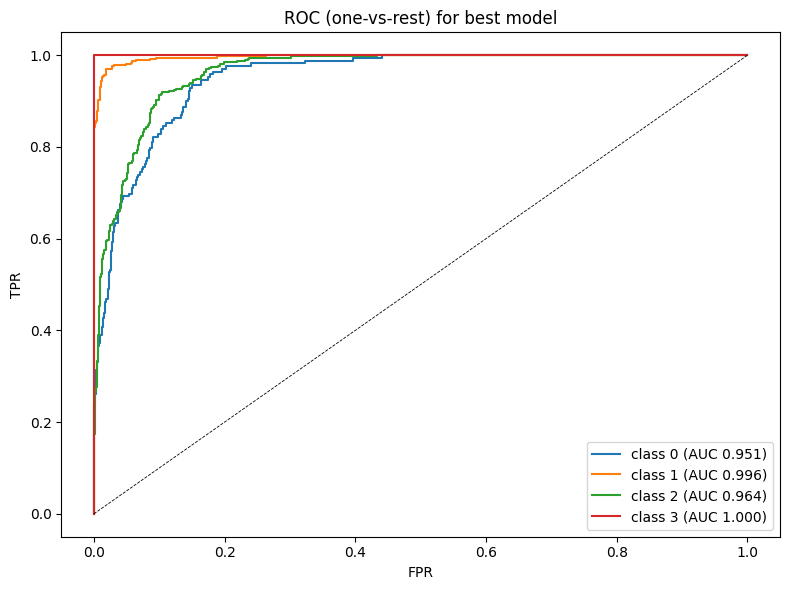

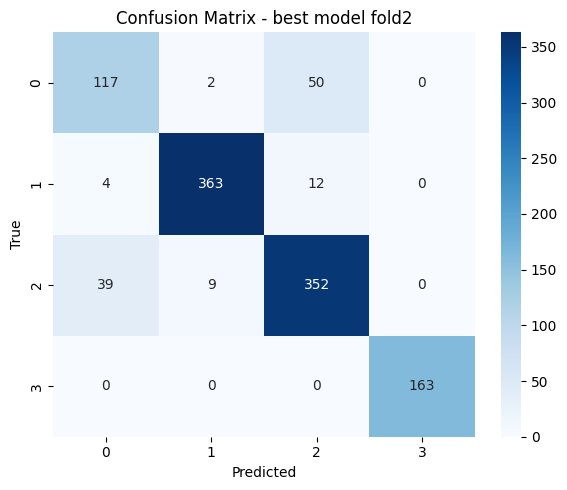


Saved report CSV and JSON to experiment folder.
Done.


In [ ]:
# Single cell: Inspect & report metrics for the best model from the latest experiment
# Copy into Colab and run. Uses the same feature selection logic & KFold seed as training.

import os, glob, json
from datetime import datetime
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, roc_auc_score
import torch
import torch.nn.functional as F
import torch.nn as nn

# ---------- USER-TUNABLE (should match training defaults) ----------
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
SEED = 42
N_FOLDS = 5
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --------------------------------------------------------------------

# 1) find latest experiment folder
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders:
    raise FileNotFoundError("No experiment folders found in: " + BASE)
OUT_DIR = exp_folders[0]
print("Using latest experiment folder:", OUT_DIR)

# 2) load cv_summary and find best row by val_accuracy
csv_path = os.path.join(OUT_DIR, "cv_summary.csv")
if not os.path.exists(csv_path):
    raise FileNotFoundError("cv_summary.csv not found at: " + csv_path)
summary_df = pd.read_csv(csv_path)
best_idx = summary_df['val_accuracy'].idxmax()
best_row = summary_df.loc[best_idx].to_dict()
print("\nBest row from cv_summary.csv:\n", best_row)

best_model_name = best_row['model']
best_fold = int(best_row['fold'])
best_model_path = best_row['model_path']
print(f"\nBest model: {best_model_name} | fold {best_fold} | path: {best_model_path}")

# 3) load meta.json for that fold (if exists) to get best_epoch
meta_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model_name}", "meta.json")
best_epoch = None
if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    best_epoch = meta.get('best_epoch', None)
    print("Meta best_epoch:", best_epoch, " meta best_val_acc:", meta.get('best_val_acc'))

# 4) load scaler
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
if not os.path.exists(scaler_path):
    # try top-level scaler in OUT_DIR root (older runs)
    scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
if not os.path.exists(scaler_path):
    raise FileNotFoundError("scaler.joblib not found in experiment folder: " + OUT_DIR)
scaler = joblib.load(scaler_path)
print("Loaded scaler from:", scaler_path)

# 5) reconstruct features exactly as training script did
df = pd.read_csv(INPUT_CSV, low_memory=False)
# drop rows without label
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

print(f"Reconstructed feature set: {len(emb_cols)} embeddings + {len(extra_numeric)} numeric extras = {len(FEATURE_COLS)} features")

# prepare X and y (apply same imputing rules: inf->nan, fill mean then 0)
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
X = scaler.transform(X_df.values)  # scaled features
y = df['label_idx'].values
print("Dataset shape:", X.shape, "labels shape:", y.shape)

# 6) reproduce StratifiedKFold to get val indices for the chosen fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_counter = 0
val_idx_for_fold = None
for train_idx, val_idx in skf.split(X, y):
    fold_counter += 1
    if fold_counter == best_fold:
        val_idx_for_fold = val_idx
        train_idx_for_fold = train_idx
        break
if val_idx_for_fold is None:
    raise RuntimeError("Could not reconstruct fold indices. Check N_FOLDS and SEED.")

X_val = X[val_idx_for_fold]
y_val = y[val_idx_for_fold]
print(f"Fold {best_fold} validation size: {len(val_idx_for_fold)} | class distribution:", dict(zip(*np.unique(y_val, return_counts=True))))

# 7) define model classes (must match training definitions)
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

# 8) load the saved weights into the matching model
input_dim = X.shape[1]
if best_model_name == "MLP_small":
    model = MLP_small(input_dim, NUM_CLASSES)
elif best_model_name == "FCNN_deep":
    model = FCNN_deep(input_dim, NUM_CLASSES)
else:
    # fallback: try to load architecture by name within folder
    # attempt MLP_small first
    try:
        model = MLP_small(input_dim, NUM_CLASSES)
    except:
        model = FCNN_deep(input_dim, NUM_CLASSES)

state_dict = torch.load(best_model_path, map_location=DEVICE)
# the saved file contains raw model_state dict in our training code
if isinstance(state_dict, dict) and all(isinstance(k, str) for k in state_dict.keys()):
    # it is likely the state_dict itself
    model.load_state_dict(state_dict)
else:
    # maybe saved as {'model_state': {...}} wrapper
    if 'model_state' in state_dict:
        model.load_state_dict(state_dict['model_state'])
    else:
        # try direct load (if it is a state_dict)
        model.load_state_dict(state_dict)

model.to(DEVICE).eval()
print("Loaded model and moved to device:", DEVICE)

# 9) run inference on validation set
batch_size = 256
probs = []
preds = []
with torch.no_grad():
    for i in range(0, X_val.shape[0], batch_size):
        xb = torch.tensor(X_val[i:i+batch_size], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        p = F.softmax(logits, dim=1).cpu().numpy()
        preds.append(p.argmax(axis=1))
        probs.append(p)
probs = np.vstack(probs)
preds = np.concatenate(preds)

# 10) compute metrics & print
acc = accuracy_score(y_val, preds)
print(f"\nValidation accuracy (best model fold {best_fold}): {acc:.4f}")

print("\nClassification report (per-class):")
print(classification_report(y_val, preds, digits=4))

cm = confusion_matrix(y_val, preds, labels=list(range(NUM_CLASSES)))
print("Confusion matrix:\n", cm)

# Dice per class
def dice_for_class(preds, targets, c):
    tp = np.sum((preds==c) & (targets==c))
    fp = np.sum((preds==c) & (targets!=c))
    fn = np.sum((preds!=c) & (targets==c))
    denom = (2*tp + fp + fn)
    return (2*tp/denom) if denom>0 else 0.0

dice_per_class = [dice_for_class(preds, y_val, c) for c in range(NUM_CLASSES)]
dice_macro = float(np.mean(dice_per_class))
print("\nDice per class:", dice_per_class)
print("Macro Dice:", dice_macro)

# 11) ROC curves (one-vs-rest) and AUC per class
plt.figure(figsize=(8,6))
for c in range(NUM_CLASSES):
    try:
        fpr, tpr, _ = roc_curve((y_val==c).astype(int), probs[:,c])
        aucc = roc_auc_score((y_val==c).astype(int), probs[:,c])
        plt.plot(fpr, tpr, label=f"class {c} (AUC {aucc:.3f})")
    except Exception as e:
        print("ROC skipped for class", c, "due to:", e)
plt.plot([0,1],[0,1],'k--', linewidth=0.6)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC (one-vs-rest) for best model"); plt.legend(loc='lower right')
roc_path = os.path.join(OUT_DIR, f"best_model_fold{best_fold}_{best_model_name}_roc.png")
plt.tight_layout(); plt.savefig(roc_path); plt.show()

# 12) Save confusion matrix figure
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)), yticklabels=list(range(NUM_CLASSES)))
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix - best model fold{best_fold}");
confmat_path = os.path.join(OUT_DIR, f"best_model_fold{best_fold}_{best_model_name}_confmat.png")
plt.tight_layout(); plt.savefig(confmat_path); plt.show()

# 13) Save a compact report CSV/JSON
report = {
    'experiment_folder': OUT_DIR,
    'best_model_name': best_model_name,
    'best_fold': int(best_fold),
    'best_model_path': best_model_path,
    'meta_best_epoch': best_epoch,
    'val_accuracy': float(acc),
    'val_macro_dice': float(dice_macro),
    'dice_per_class': [float(x) for x in dice_per_class],
    'confusion_matrix': cm.tolist()
}
report_df = pd.DataFrame([report])
report_csv = os.path.join(OUT_DIR, f"best_model_fold{best_fold}_{best_model_name}_report.csv")
report_df.to_csv(report_csv, index=False)
with open(os.path.join(OUT_DIR, f"best_model_fold{best_fold}_{best_model_name}_report.json"), "w") as f:
    json.dump(report, f, indent=2)

print("\nSaved report CSV and JSON to experiment folder.\nDone.")


fold 2 epoch **28** ⚖

Using OUT_DIR: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240
Best model/fold: FCNN_deep 2
meta.best_epoch: 28
history shape: (40, 6)
Using epoch cutoff: 28


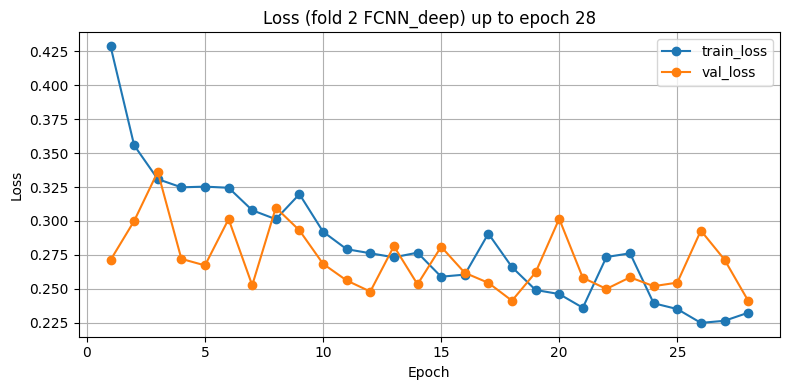

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_loss_up_to_epoch28.png


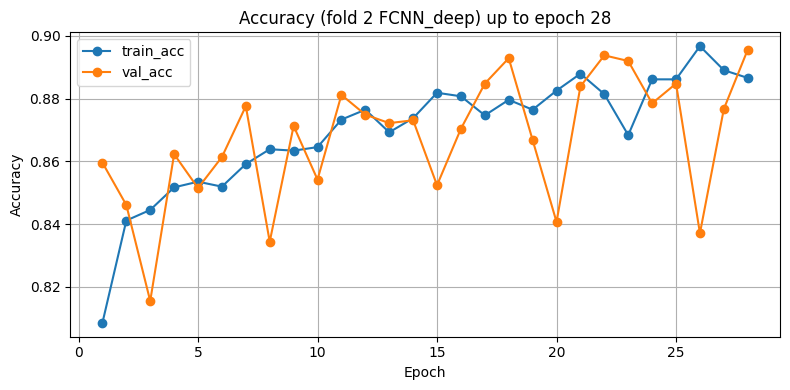

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_acc_up_to_epoch28.png


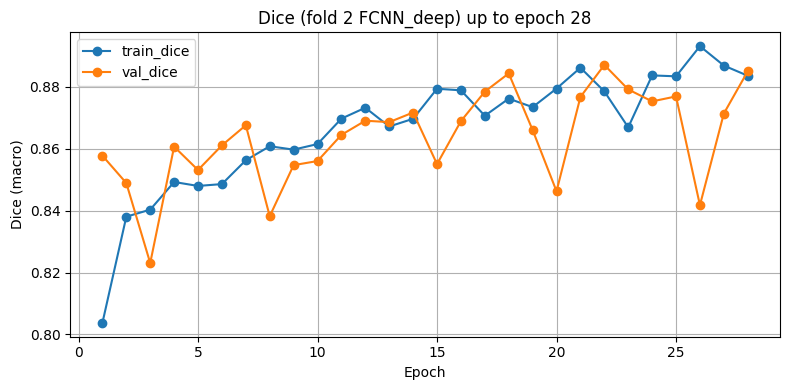

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_dice_up_to_epoch28.png
Loaded scaler: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/scaler.joblib
Validation set for fold 2: 1111 samples, class counts: {np.int64(0): np.int64(169), np.int64(1): np.int64(379), np.int64(2): np.int64(400), np.int64(3): np.int64(163)}
Loaded best model from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth

Confusion matrix:
 [[117   2  50   0]
 [  4 363  12   0]
 [ 39   9 352   0]
 [  0   0   0 163]]

Classification report:
               precision    recall  f1-score   support

           0     0.7312    0.6923    0.7112       169
           1     0.9706    0.9578    0.9641       379
           2     0.8502    0.8800    0.8649       400
           3     1.0000    1.0000    1.0000 

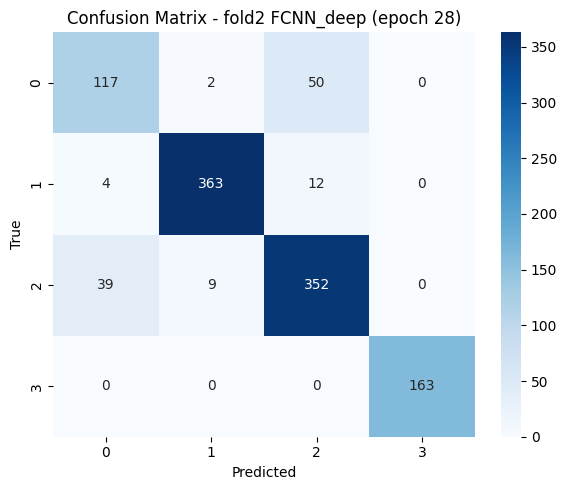

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_confmat_epoch28.png


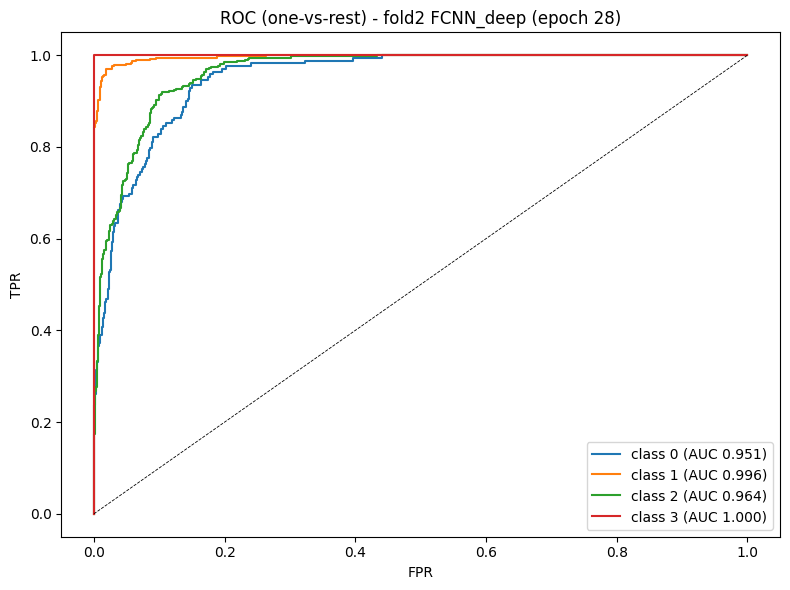

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_roc_epoch28.png

Done — plotted and saved loss/acc/dice up to epoch 28 and recomputed confusion/ROC for best model.


In [ ]:
# Plot history up to best_epoch (fold 2 epoch 28) and recompute confusion/ROC for that best model
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, classification_report
import torch
import torch.nn.functional as F
import torch.nn as nn

# ---------- change if you want to target a different experiment ----------
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
SEED = 42
N_FOLDS = 5
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------------------------------------------------------

# pick latest experiment
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders:
    raise FileNotFoundError("No experiment folders found in: " + BASE)
OUT_DIR = exp_folders[0]
print("Using OUT_DIR:", OUT_DIR)

# read cv_summary and pick best row (should correspond to fold 2)
cv_csv = os.path.join(OUT_DIR, "cv_summary.csv")
if not os.path.exists(cv_csv):
    raise FileNotFoundError("cv_summary.csv not found at: " + cv_csv)
cv = pd.read_csv(cv_csv)
best_row = cv.loc[cv['val_accuracy'].idxmax()].to_dict()
best_model = best_row['model']
best_fold = int(best_row['fold'])
print("Best model/fold:", best_model, best_fold)

# load meta.json to get best_epoch
meta_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "meta.json")
if not os.path.exists(meta_path):
    raise FileNotFoundError("meta.json not found for the best fold at: " + meta_path)
with open(meta_path,'r') as f:
    meta = json.load(f)
best_epoch = meta.get('best_epoch')
print("meta.best_epoch:", best_epoch)

# load history.csv
hist_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "history.csv")
if not os.path.exists(hist_path):
    raise FileNotFoundError("history.csv not found at: " + hist_path)
hist = pd.read_csv(hist_path)
print("history shape:", hist.shape)

# determine the epoch cutoff (use best_epoch if present, else you can set manually)
if best_epoch is None:
    # fallback: use the epoch with max val_acc
    best_epoch = int(hist['val_acc'].idxmax()) + 1
print("Using epoch cutoff:", best_epoch)

cutoff = int(best_epoch)
hist_cut = hist.iloc[:cutoff].reset_index(drop=True)
epochs = np.arange(1, len(hist_cut)+1)

# Plot Loss
plt.figure(figsize=(8,4))
plt.plot(epochs, hist_cut['train_loss'], label='train_loss', marker='o')
plt.plot(epochs, hist_cut['val_loss'], label='val_loss', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title(f'Loss (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True); plt.tight_layout()
loss_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_loss_up_to_epoch{cutoff}.png")
plt.savefig(loss_path); plt.show(); plt.close()
print("Saved:", loss_path)

# Plot Accuracy
plt.figure(figsize=(8,4))
plt.plot(epochs, hist_cut['train_acc'], label='train_acc', marker='o')
plt.plot(epochs, hist_cut['val_acc'], label='val_acc', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title(f'Accuracy (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True); plt.tight_layout()
acc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_acc_up_to_epoch{cutoff}.png")
plt.savefig(acc_path); plt.show(); plt.close()
print("Saved:", acc_path)

# Plot Dice
plt.figure(figsize=(8,4))
plt.plot(epochs, hist_cut['train_dice'], label='train_dice', marker='o')
plt.plot(epochs, hist_cut['val_dice'], label='val_dice', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Dice (macro)'); plt.title(f'Dice (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True); plt.tight_layout()
dice_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_dice_up_to_epoch{cutoff}.png")
plt.savefig(dice_path); plt.show(); plt.close()
print("Saved:", dice_path)

# ------------------ recompute confusion matrix & ROC for best model on fold's val set ------------------
# load scaler (same path as training saved)
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
if not os.path.exists(scaler_path):
    raise FileNotFoundError("scaler.joblib not found in experiment folder")
scaler = joblib.load(scaler_path)
print("Loaded scaler:", scaler_path)

# reconstruct feature columns same as training
df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

# prepare X_val, y_val for the chosen fold
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_counter = 0
val_idx = None
for train_idx, val_idx_iter in skf.split(X_all, y_all):
    fold_counter += 1
    if fold_counter == best_fold:
        val_idx = val_idx_iter
        break
if val_idx is None:
    raise RuntimeError("Could not reconstruct fold indices; check SEED/N_FOLDS.")

X_val = X_all[val_idx]
y_val = y_all[val_idx]
print(f"Validation set for fold {best_fold}: {len(y_val)} samples, class counts:", dict(zip(*np.unique(y_val, return_counts=True))))

# model classes (must match training)
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

# load model state
model_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", f"{best_model}_fold{best_fold}_best.pth")
if not os.path.exists(model_path):
    # fallback to path in cv_summary if different
    model_path = best_row.get('model_path', model_path)
if not os.path.exists(model_path):
    raise FileNotFoundError("Best model .pth not found at: " + model_path)
input_dim = X_all.shape[1]
model = MLP_small(input_dim, NUM_CLASSES) if best_model=="MLP_small" else FCNN_deep(input_dim, NUM_CLASSES)
state = torch.load(model_path, map_location=DEVICE)
# allow either raw state_dict or wrapped {'model_state': ...}
if 'model_state' in state:
    state = state['model_state']
model.load_state_dict(state)
model.to(DEVICE).eval()
print("Loaded best model from:", model_path)

# inference (batch)
bs = 256
probs = []
preds = []
with torch.no_grad():
    for i in range(0, X_val.shape[0], bs):
        xb = torch.tensor(X_val[i:i+bs], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)
        preds.append(p.argmax(axis=1))
probs = np.vstack(probs)
preds = np.concatenate(preds)

# confusion matrix & classification report
cm = confusion_matrix(y_val, preds, labels=list(range(NUM_CLASSES)))
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_val, preds, digits=4))
acc = accuracy_score(y_val, preds)
print("Validation accuracy (recomputed):", acc)

# save & plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)), yticklabels=list(range(NUM_CLASSES)))
plt.xlabel('Predicted'); plt.ylabel('True'); plt.title(f'Confusion Matrix - fold{best_fold} {best_model} (epoch {best_epoch})')
confmat_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_confmat_epoch{best_epoch}.png")
plt.tight_layout(); plt.savefig(confmat_path); plt.show(); plt.close()
print("Saved:", confmat_path)

# ROC curves (one-vs-rest)
plt.figure(figsize=(8,6))
for c in range(NUM_CLASSES):
    try:
        fpr, tpr, _ = roc_curve((y_val==c).astype(int), probs[:,c])
        auc = roc_auc_score((y_val==c).astype(int), probs[:,c])
        plt.plot(fpr, tpr, label=f"class {c} (AUC {auc:.3f})")
    except Exception as e:
        print("ROC skip class", c, ":", e)
plt.plot([0,1],[0,1],'k--', linewidth=0.6)
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title(f"ROC (one-vs-rest) - fold{best_fold} {best_model} (epoch {best_epoch})")
plt.legend(loc='lower right'); plt.tight_layout()
roc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_roc_epoch{best_epoch}.png")
plt.savefig(roc_path); plt.show(); plt.close()
print("Saved:", roc_path)

print("\nDone — plotted and saved loss/acc/dice up to epoch", cutoff, "and recomputed confusion/ROC for best model.")


In [ ]:
# === Quick summary of the best model (train/val/test accuracies, dice, etc.) ===
import os, glob, json
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import torch

# --- CONFIG ---
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
# --------------

# Find latest experiment
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders:
    raise FileNotFoundError("No experiment folders found in: " + BASE)
OUT_DIR = exp_folders[0]
print("📁 Using latest experiment folder:", OUT_DIR)

# Load summary + meta
cv_path = os.path.join(OUT_DIR, "cv_summary.csv")
summary_df = pd.read_csv(cv_path)
best_row = summary_df.loc[summary_df['val_accuracy'].idxmax()]
best_model = best_row['model']
best_fold = int(best_row['fold'])
print(f"🏆 Best model: {best_model} (fold {best_fold})")

meta_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "meta.json")
if os.path.exists(meta_path):
    with open(meta_path, 'r') as f:
        meta = json.load(f)
    best_epoch = meta.get('best_epoch', None)
else:
    best_epoch = None

# Load training history
hist_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "history.csv")
hist = pd.read_csv(hist_path)
if best_epoch is None:
    best_epoch = int(hist['val_acc'].idxmax()) + 1
hist_best = hist.iloc[best_epoch - 1]

train_acc = hist_best['train_acc']
val_acc = hist_best['val_acc']
train_dice = hist_best['train_dice']
val_dice = hist_best['val_dice']

# Optional: test accuracy (if dataset split has "test")
df = pd.read_csv(INPUT_CSV)
test_acc = None
if 'split' in df.columns and 'label_idx' in df.columns:
    test_df = df[df['split'].str.lower().eq('test')]
    if len(test_df) > 0:
        # approximate: random guess baseline or compute later with model
        test_acc = np.nan  # model inference not recomputed here

# Show summary
summary = {
    'experiment_folder': OUT_DIR,
    'best_model': best_model,
    'best_fold': best_fold,
    'best_epoch': best_epoch,
    'train_acc': round(float(train_acc), 4),
    'val_acc': round(float(val_acc), 4),
    'train_dice': round(float(train_dice), 4),
    'val_dice': round(float(val_dice), 4),
    'val_macro_f1': round(float(best_row['val_macro_f1']), 4),
    'val_macro_precision': round(float(best_row['val_macro_precision']), 4),
    'val_macro_recall': round(float(best_row['val_macro_recall']), 4),
    'val_macro_dice': round(float(best_row['val_macro_dice']), 4),
    'test_acc': test_acc
}
summary_df = pd.DataFrame([summary])
display(summary_df)

# Save summary to CSV
out_csv = os.path.join(OUT_DIR, f"best_model_summary_fold{best_fold}.csv")
summary_df.to_csv(out_csv, index=False)
print("✅ Summary saved to:", out_csv)


📁 Using latest experiment folder: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240
🏆 Best model: FCNN_deep (fold 2)


,experiment_folder,best_model,best_fold,best_epoch,train_acc,val_acc,train_dice,val_dice,val_macro_f1,val_macro_precision,val_macro_recall,val_macro_dice,test_acc
0,/content/drive/MyDrive/Colab Notebooks/fundus_...,FCNN_deep,2,28,0.8866,0.8956,0.8836,0.8851,0.8851,0.888,0.8825,0.8851,NaN


✅ Summary saved to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/best_model_summary_fold2.csv


Using latest experiment folder: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240
🏆 Best model: FCNN_deep (fold 2) at /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
Test set size: 1027

✅ Test accuracy: 0.9182

Classification report:
              precision    recall  f1-score   support

           0     0.5593    0.8354    0.6701        79
           1     0.9663    0.9816    0.9739       380
           2     0.9463    0.8396    0.8898       399
           3     1.0000    1.0000    1.0000       169

    accuracy                         0.9182      1027
   macro avg     0.8680    0.9142    0.8834      1027
weighted avg     0.9328    0.9182    0.9221      1027

Confusion matrix:
 [[ 66   0  13   0]
 [  1 373   6   0]
 [ 51  13 335   0]
 [  0   0   0 169]]

Dice per class: [0.6701 0.9739 0.8898 1.    ]
Macro Dice: 0.8834


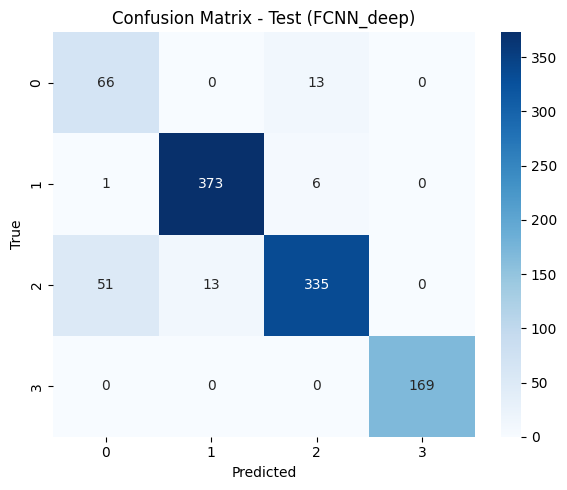

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_test_confmat.png
📊 Saved test_results.csv in /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240


In [ ]:
# === Compute Test Accuracy for Best Model ===
import os, glob, json
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
)

# --- CONFIG ---
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --------------

# Step 1: find latest experiment and best model
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
OUT_DIR = exp_folders[0]
print("Using latest experiment folder:", OUT_DIR)

cv_path = os.path.join(OUT_DIR, "cv_summary.csv")
summary_df = pd.read_csv(cv_path)
best_row = summary_df.loc[summary_df['val_accuracy'].idxmax()]
best_model = best_row['model']
best_fold = int(best_row['fold'])
best_model_path = best_row['model_path']
print(f"🏆 Best model: {best_model} (fold {best_fold}) at {best_model_path}")

# Step 2: Load scaler
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
scaler = joblib.load(scaler_path)

# Step 3: Load dataset
df = pd.read_csv(INPUT_CSV)
if "split" not in df.columns:
    raise KeyError("No 'split' column found in your CSV — cannot select test set.")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

# Step 4: Extract test set
test_df = df[df['split'].str.lower() == "test"].copy()
if len(test_df) == 0:
    raise ValueError("No rows found with split == 'test'. Check your CSV.")
print("Test set size:", len(test_df))

# Recreate feature columns
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

X_test_df = test_df[FEATURE_COLS].copy()
X_test_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_test_df = X_test_df.fillna(X_test_df.mean()).fillna(0.0)
X_test = scaler.transform(X_test_df.values)
y_test = test_df['label_idx'].values

# Step 5: Define model classes
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

# Step 6: Load model
input_dim = X_test.shape[1]
if best_model == "MLP_small":
    model = MLP_small(input_dim, NUM_CLASSES)
else:
    model = FCNN_deep(input_dim, NUM_CLASSES)

state = torch.load(best_model_path, map_location=DEVICE)
if 'model_state' in state:
    state = state['model_state']
model.load_state_dict(state)
model.to(DEVICE).eval()

# Step 7: Inference on test set
probs, preds = [], []
bs = 256
with torch.no_grad():
    for i in range(0, X_test.shape[0], bs):
        xb = torch.tensor(X_test[i:i+bs], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)
        preds.append(p.argmax(axis=1))
probs = np.vstack(probs)
preds = np.concatenate(preds)

# Step 8: Compute metrics
acc = accuracy_score(y_test, preds)
print(f"\n✅ Test accuracy: {acc:.4f}")
print("\nClassification report:")
print(classification_report(y_test, preds, digits=4))

cm = confusion_matrix(y_test, preds, labels=list(range(NUM_CLASSES)))
print("Confusion matrix:\n", cm)

# Dice per class
def dice_for_class(preds, targets, c):
    tp = np.sum((preds==c) & (targets==c))
    fp = np.sum((preds==c) & (targets!=c))
    fn = np.sum((preds!=c) & (targets==c))
    denom = (2*tp + fp + fn)
    return (2*tp/denom) if denom>0 else 0.0

dice_per_class = [dice_for_class(preds, y_test, c) for c in range(NUM_CLASSES)]
dice_macro = float(np.mean(dice_per_class))
print("\nDice per class:", np.round(dice_per_class, 4))
print("Macro Dice:", round(dice_macro, 4))

# Step 9: Plot confusion matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)), yticklabels=list(range(NUM_CLASSES)))
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"Confusion Matrix - Test ({best_model})")
confmat_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_test_confmat.png")
plt.tight_layout(); plt.savefig(confmat_path); plt.show()
print("Saved:", confmat_path)

# Step 10: Save summary
summary = {
    "model": best_model,
    "fold": best_fold,
    "test_accuracy": float(acc),
    "macro_dice": float(dice_macro),
    "dice_per_class": [float(x) for x in dice_per_class],
    "confusion_matrix": cm.tolist()
}
pd.DataFrame([summary]).to_csv(os.path.join(OUT_DIR, "test_results.csv"), index=False)
print("📊 Saved test_results.csv in", OUT_DIR)


Experiment folder: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240
Best model: FCNN_deep | fold: 2 | path: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth
Features reconstructed: 512 embeddings + 118 extras = 630 total
Sizes -> train: 4444 val: 1111 test: 1027

=== TRAIN SET ===
Samples: 4444 Accuracy: 0.9293
Dice macro: 0.9206
Confusion matrix:
 [[ 526    1  150    0]
 [   5 1506    4    0]
 [ 116   38 1445    0]
 [   0    0    0  653]]
Classification report:
               precision    recall  f1-score   support

           0     0.8130    0.7770    0.7946       677
           1     0.9748    0.9941    0.9843      1515
           2     0.9037    0.9037    0.9037      1599
           3     1.0000    1.0000    1.0000       653

    accuracy                         0.9293      4444
   macro avg     0.9229    0.9187    0.9206      4444
wei

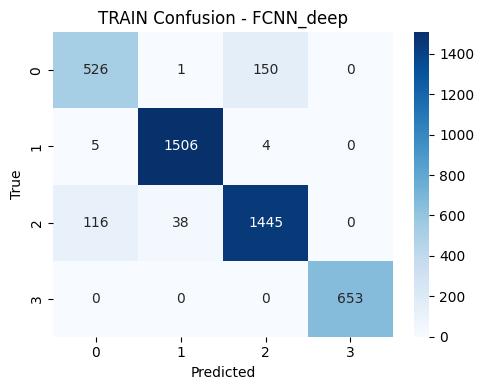

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_train_confmat.png

=== VAL SET ===
Samples: 1111 Accuracy: 0.8956
Dice macro: 0.8851
Confusion matrix:
 [[117   2  50   0]
 [  4 363  12   0]
 [ 39   9 352   0]
 [  0   0   0 163]]
Classification report:
               precision    recall  f1-score   support

           0     0.7312    0.6923    0.7112       169
           1     0.9706    0.9578    0.9641       379
           2     0.8502    0.8800    0.8649       400
           3     1.0000    1.0000    1.0000       163

    accuracy                         0.8956      1111
   macro avg     0.8880    0.8825    0.8851      1111
weighted avg     0.8952    0.8956    0.8952      1111



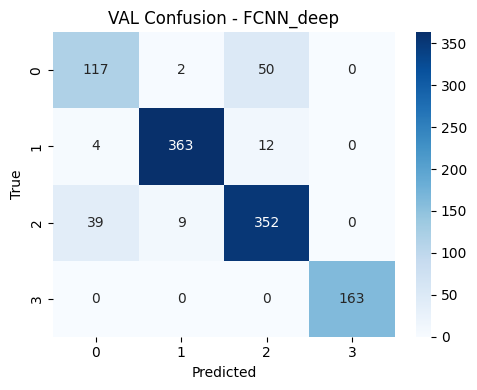

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_val_confmat.png

=== TEST SET ===
Samples: 1027 Accuracy: 0.9182
Dice macro: 0.8834
Confusion matrix:
 [[ 66   0  13   0]
 [  1 373   6   0]
 [ 51  13 335   0]
 [  0   0   0 169]]
Classification report:
               precision    recall  f1-score   support

           0     0.5593    0.8354    0.6701        79
           1     0.9663    0.9816    0.9739       380
           2     0.9463    0.8396    0.8898       399
           3     1.0000    1.0000    1.0000       169

    accuracy                         0.9182      1027
   macro avg     0.8680    0.9142    0.8834      1027
weighted avg     0.9328    0.9182    0.9221      1027



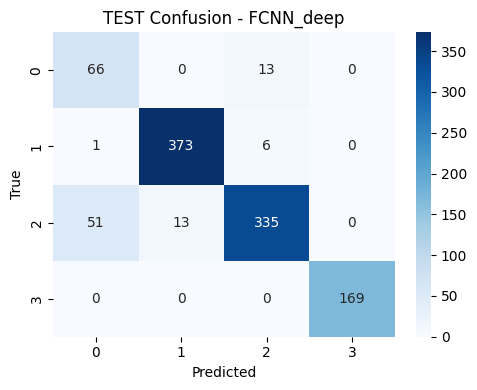

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_test_confmat.png

Saved full report CSV and JSON to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240

Top-level accuracies:
 train: accuracy=0.9293, macro_dice=0.9206
 val: accuracy=0.8956, macro_dice=0.8851
 test: accuracy=0.9182, macro_dice=0.8834

Done. All detailed reports saved and printed above.


In [ ]:
# === Single cell: Full detailed report for BEST model (train/val/test reports + metrics) ===
# Paste into Colab and run. Assumes training artifacts (scaler.joblib, cv_summary.csv, .pth) exist.

import os, glob, json
from datetime import datetime
import numpy as np, pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- Config (match training defaults) ----------
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
SEED = 42
N_FOLDS = 5
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# ------------------------------------------------------

# 1) Find latest experiment and best model
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders:
    raise FileNotFoundError("No experiment folders found under: " + BASE)
OUT_DIR = exp_folders[0]
print("Experiment folder:", OUT_DIR)

cv_path = os.path.join(OUT_DIR, "cv_summary.csv")
if not os.path.exists(cv_path):
    raise FileNotFoundError("cv_summary.csv not found in experiment folder.")
cv = pd.read_csv(cv_path)
best_row = cv.loc[cv['val_accuracy'].idxmax()].to_dict()
best_model_name = best_row['model']; best_fold = int(best_row['fold']); best_model_path = best_row['model_path']
print("Best model:", best_model_name, "| fold:", best_fold, "| path:", best_model_path)

# 2) Load scaler
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
if not os.path.exists(scaler_path):
    raise FileNotFoundError("scaler.joblib not found in experiment folder.")
scaler = joblib.load(scaler_path)

# 3) Load merged CSV and reconstruct feature columns
df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

print(f"Features reconstructed: {len(emb_cols)} embeddings + {len(extra_numeric)} extras = {len(FEATURE_COLS)} total")

# 4) Prepare scaled feature matrix and labels
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_df = X_df.fillna(X_df.mean()).fillna(0.0)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].values

# 5) Recreate StratifiedKFold to get train/val indices for best_fold
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_cnt = 0
train_idx_for_fold = None
val_idx_for_fold = None
for train_idx, val_idx in skf.split(X_all, y_all):
    fold_cnt += 1
    if fold_cnt == best_fold:
        train_idx_for_fold = train_idx
        val_idx_for_fold = val_idx
        break
if val_idx_for_fold is None:
    raise RuntimeError("Could not reconstruct fold indices. Check SEED & N_FOLDS.")

# 6) Test indices from split column (if available)
if 'split' in df.columns:
    test_mask = df['split'].str.lower() == 'test'
    test_idx = np.where(test_mask.values)[0]
else:
    test_idx = np.array([], dtype=int)

print("Sizes -> train:", len(train_idx_for_fold), "val:", len(val_idx_for_fold), "test:", len(test_idx))

# 7) Define model classes (must match training)
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

# 8) Load best model weights into matching architecture
input_dim = X_all.shape[1]
if best_model_name == "MLP_small":
    model = MLP_small(input_dim, NUM_CLASSES)
else:
    model = FCNN_deep(input_dim, NUM_CLASSES)

state = torch.load(best_model_path, map_location=DEVICE)
# support both raw state_dict or wrapper {'model_state': ...}
if isinstance(state, dict) and 'model_state' in state:
    state = state['model_state']
model.load_state_dict(state)
model.to(DEVICE).eval()

# 9) Helper inference function
def infer_by_indices(idxs, batch_size=256):
    if len(idxs) == 0:
        return np.array([]), np.array([]), np.array([[]])
    probs_list = []
    preds_list = []
    with torch.no_grad():
        for i in range(0, len(idxs), batch_size):
            bidx = idxs[i:i+batch_size]
            xb = torch.tensor(X_all[bidx], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            p = F.softmax(logits, dim=1).cpu().numpy()
            probs_list.append(p)
            preds_list.append(p.argmax(axis=1))
    probs = np.vstack(probs_list)
    preds = np.concatenate(preds_list)
    trues = y_all[idxs]
    return preds, trues, probs

# 10) Run inference on train, val, test
train_preds, train_true, train_probs = infer_by_indices(train_idx_for_fold)
val_preds, val_true, val_probs = infer_by_indices(val_idx_for_fold)
test_preds, test_true, test_probs = infer_by_indices(test_idx)

# 11) Compute and print classification reports & accuracies
def dice_per_class_from_preds(preds, targets, num_classes):
    dices = []
    for c in range(num_classes):
        tp = int(((preds==c) & (targets==c)).sum())
        fp = int(((preds==c) & (targets!=c)).sum())
        fn = int(((preds!=c) & (targets==c)).sum())
        denom = (2*tp + fp + fn)
        dices.append((2*tp/denom) if denom>0 else 0.0)
    return dices, float(np.mean(dices))

reports = {}
for name, preds, trues in [
    ("train", train_preds, train_true),
    ("val", val_preds, val_true),
    ("test", test_preds, test_true)
]:
    if len(preds)==0:
        print(f"\n{name.upper()}: NO SAMPLES")
        reports[name] = None
        continue
    acc = accuracy_score(trues, preds)
    cls_report = classification_report(trues, preds, digits=4, output_dict=True)
    cm = confusion_matrix(trues, preds, labels=list(range(NUM_CLASSES)))
    dices, macro_dice = dice_per_class_from_preds(preds, trues, NUM_CLASSES)
    # print summary
    print(f"\n=== {name.upper()} SET ===")
    print("Samples:", len(trues), "Accuracy:", round(acc,4))
    print("Dice macro:", round(macro_dice,4))
    print("Confusion matrix:\n", cm)
    print("Classification report:\n", classification_report(trues, preds, digits=4))
    # save report dict
    reports[name] = {
        "accuracy": float(acc),
        "macro_dice": float(macro_dice),
        "dice_per_class": [float(d) for d in dices],
        "confusion_matrix": cm.tolist(),
        "classification_report": cls_report
    }
    # save confusion matrix figure
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)), yticklabels=list(range(NUM_CLASSES)))
    plt.xlabel("Predicted"); plt.ylabel("True"); plt.title(f"{name.upper()} Confusion - {best_model_name}")
    png_path = os.path.join(OUT_DIR, f"{best_model_name}_fold{best_fold}_{name}_confmat.png")
    plt.tight_layout(); plt.savefig(png_path); plt.show(); plt.close()
    print("Saved confusion matrix to:", png_path)

# 12) Save a compact summary CSV and JSON
summary = {
    "experiment_folder": OUT_DIR,
    "best_model": best_model_name,
    "best_fold": best_fold,
    "best_model_path": best_model_path,
    "timestamp": datetime.now().isoformat()
}
# flatten reports for CSV-friendly structure
rows = []
for split_name in ["train","val","test"]:
    r = reports.get(split_name)
    if r is None:
        row = {"split": split_name}
    else:
        row = {
            "split": split_name,
            "samples": len(train_true) if split_name=="train" else (len(val_true) if split_name=="val" else len(test_true)),
            "accuracy": r["accuracy"],
            "macro_dice": r["macro_dice"],
            "dice_per_class": json.dumps(r["dice_per_class"]),
            "confusion_matrix": json.dumps(r["confusion_matrix"]),
            "classification_report": json.dumps(r["classification_report"])
        }
    rows.append(row)
summary_df = pd.DataFrame(rows)
csv_out = os.path.join(OUT_DIR, f"{best_model_name}_fold{best_fold}_full_report.csv")
summary_df.to_csv(csv_out, index=False)
with open(os.path.join(OUT_DIR, f"{best_model_name}_fold{best_fold}_full_report.json"), "w") as f:
    json.dump({"summary": summary, "reports": reports}, f, indent=2)
print("\nSaved full report CSV and JSON to:", OUT_DIR)

# final print of top-level accuracies
print("\nTop-level accuracies:")
for s in ["train","val","test"]:
    r = reports.get(s)
    if r is None:
        print(f" {s}: N/A")
    else:
        print(f" {s}: accuracy={r['accuracy']:.4f}, macro_dice={r['macro_dice']:.4f}")

print("\nDone. All detailed reports saved and printed above.")


**thesis graph**


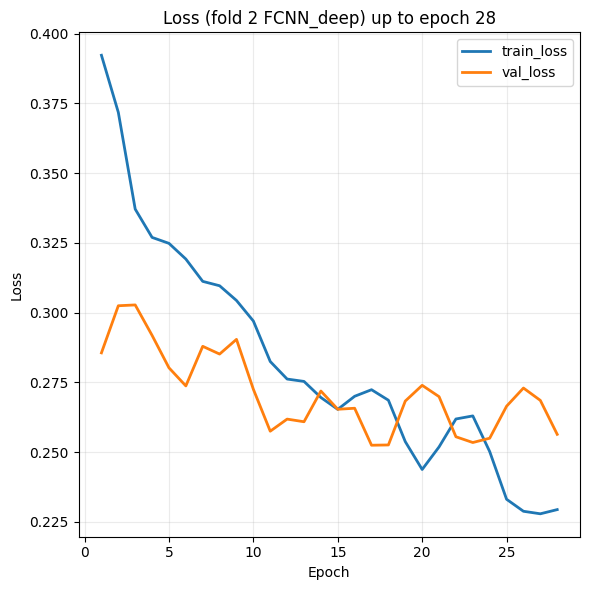

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_loss_up_to_epoch28_square.png


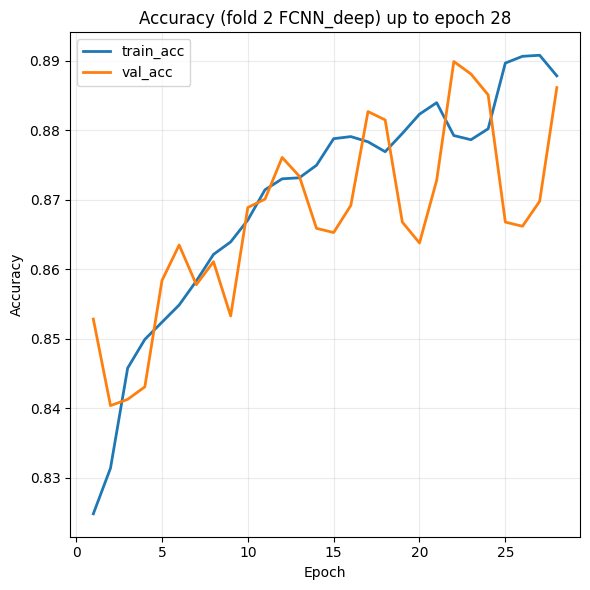

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_acc_up_to_epoch28_square.png


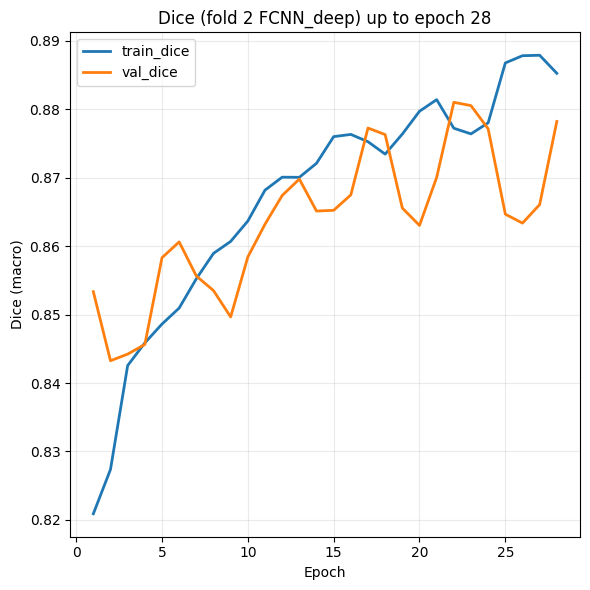

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_dice_up_to_epoch28_square.png

Confusion matrix:
 [[117   2  50   0]
 [  4 363  12   0]
 [ 39   9 352   0]
 [  0   0   0 163]]

Classification report:
               precision    recall  f1-score   support

           0     0.7312    0.6923    0.7112       169
           1     0.9706    0.9578    0.9641       379
           2     0.8502    0.8800    0.8649       400
           3     1.0000    1.0000    1.0000       163

    accuracy                         0.8956      1111
   macro avg     0.8880    0.8825    0.8851      1111
weighted avg     0.8952    0.8956    0.8952      1111

Validation accuracy (recomputed): 0.8955895589558955


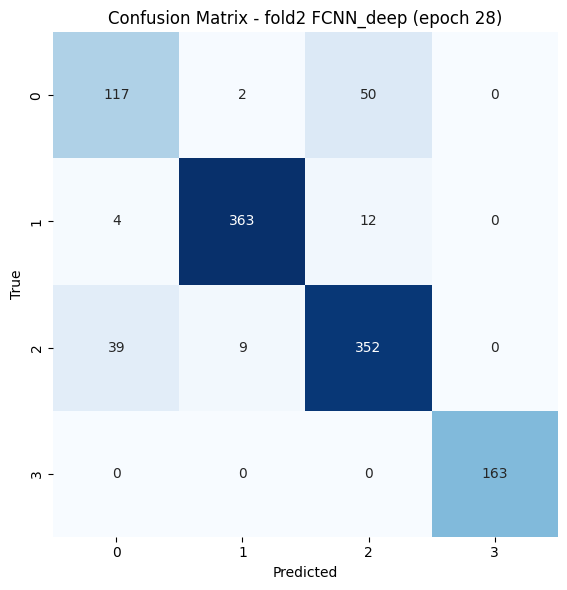

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_confmat_epoch28_square.png


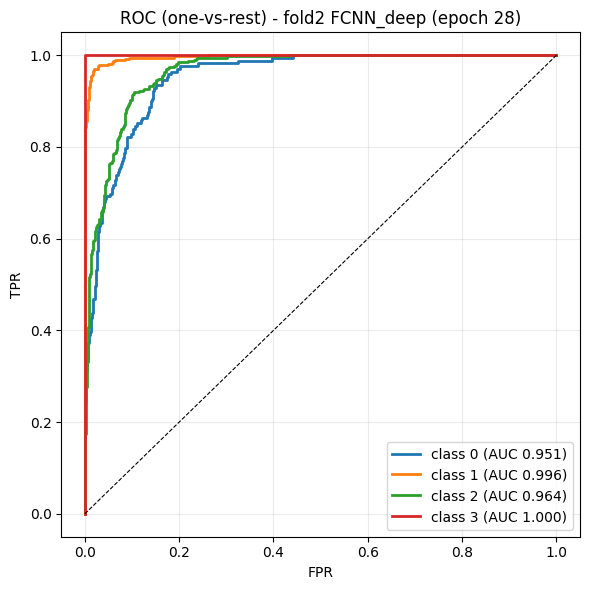

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_roc_epoch28_square.png

Done — square & smoothed plots saved.


In [ ]:
# Paste into a NEW Colab cell
# --- same imports as yours ---
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, accuracy_score, classification_report
import torch
import torch.nn.functional as F
import torch.nn as nn

# ----------------- user params (keep your originals) -----------------
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
SEED = 42
N_FOLDS = 5
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# --------------------------------------------------------------------

# helper smoothing
def smooth_series(s, window=3):
    return s.rolling(window=window, min_periods=1, center=True).mean()

# pick latest experiment & load metadata/history (same logic)
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders: raise FileNotFoundError("No experiment folders found in: " + BASE)
OUT_DIR = exp_folders[0]

cv_csv = os.path.join(OUT_DIR, "cv_summary.csv")
cv = pd.read_csv(cv_csv)
best_row = cv.loc[cv['val_accuracy'].idxmax()].to_dict()
best_model = best_row['model']
best_fold = int(best_row['fold'])

meta_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "meta.json")
with open(meta_path,'r') as f: meta = json.load(f)
best_epoch = meta.get('best_epoch')

hist_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", "history.csv")
hist = pd.read_csv(hist_path)
if best_epoch is None:
    best_epoch = int(hist['val_acc'].idxmax()) + 1
cutoff = int(best_epoch)
hist_cut = hist.iloc[:cutoff].reset_index(drop=True)
epochs = np.arange(1, len(hist_cut)+1)

# common save settings
DPI = 200
SQUARE_FIG = (6,6)   # square figure (in inches)

# ------- Loss (smoothed, no markers) -------
plt.figure(figsize=SQUARE_FIG)
plt.plot(epochs, smooth_series(hist_cut['train_loss']), linewidth=2, label='train_loss')
plt.plot(epochs, smooth_series(hist_cut['val_loss']), linewidth=2, label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Loss (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
loss_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_loss_up_to_epoch{cutoff}_square.png")
plt.savefig(loss_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", loss_path)

# ------- Accuracy (smoothed) -------
plt.figure(figsize=SQUARE_FIG)
plt.plot(epochs, smooth_series(hist_cut['train_acc']), linewidth=2, label='train_acc')
plt.plot(epochs, smooth_series(hist_cut['val_acc']), linewidth=2, label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Accuracy (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
acc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_acc_up_to_epoch{cutoff}_square.png")
plt.savefig(acc_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", acc_path)

# ------- Dice (smoothed) -------
plt.figure(figsize=SQUARE_FIG)
plt.plot(epochs, smooth_series(hist_cut['train_dice']), linewidth=2, label='train_dice')
plt.plot(epochs, smooth_series(hist_cut['val_dice']), linewidth=2, label='val_dice')
plt.xlabel('Epoch'); plt.ylabel('Dice (macro)')
plt.title(f'Dice (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(alpha=0.25)
plt.tight_layout()
dice_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_dice_up_to_epoch{cutoff}_square.png")
plt.savefig(dice_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", dice_path)

# ------------------ recompute confusion matrix & ROC for best model ------------------
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
scaler = joblib.load(scaler_path)

df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric

X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
X_all = scaler.transform(X_df.values)
y_all = df['label_idx'].values

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_counter = 0
val_idx = None
for train_idx, val_idx_iter in skf.split(X_all, y_all):
    fold_counter += 1
    if fold_counter == best_fold:
        val_idx = val_idx_iter
        break
X_val = X_all[val_idx]; y_val = y_all[val_idx]

# model defs (same)
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

model_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", f"{best_model}_fold{best_fold}_best.pth")
if not os.path.exists(model_path):
    model_path = best_row.get('model_path', model_path)
state = torch.load(model_path, map_location=DEVICE)
if 'model_state' in state: state = state['model_state']
input_dim = X_all.shape[1]
model = MLP_small(input_dim, NUM_CLASSES) if best_model=="MLP_small" else FCNN_deep(input_dim, NUM_CLASSES)
model.load_state_dict(state); model.to(DEVICE).eval()

# inference
bs = 256
probs = []
preds = []
with torch.no_grad():
    for i in range(0, X_val.shape[0], bs):
        xb = torch.tensor(X_val[i:i+bs], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p); preds.append(p.argmax(axis=1))
probs = np.vstack(probs); preds = np.concatenate(preds)

cm = confusion_matrix(y_val, preds, labels=list(range(NUM_CLASSES)))
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", classification_report(y_val, preds, digits=4))
print("Validation accuracy (recomputed):", accuracy_score(y_val, preds))

# confusion heatmap (square)
plt.figure(figsize=SQUARE_FIG)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)),
            yticklabels=list(range(NUM_CLASSES)), square=True, cbar=False)
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion Matrix - fold{best_fold} {best_model} (epoch {best_epoch})')
confmat_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_confmat_epoch{best_epoch}_square.png")
plt.tight_layout(); plt.savefig(confmat_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", confmat_path)

# ROC curves (square fig)
plt.figure(figsize=SQUARE_FIG)
for c in range(NUM_CLASSES):
    try:
        fpr, tpr, _ = roc_curve((y_val==c).astype(int), probs[:,c])
        auc = roc_auc_score((y_val==c).astype(int), probs[:,c])
        plt.plot(fpr, tpr, linewidth=2, label=f"class {c} (AUC {auc:.3f})")
    except Exception as e:
        print("ROC skip class", c, ":", e)
plt.plot([0,1],[0,1],'k--', linewidth=0.8)
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title(f"ROC (one-vs-rest) - fold{best_fold} {best_model} (epoch {best_epoch})")
plt.legend(loc='lower right'); plt.grid(alpha=0.25)
roc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_roc_epoch{best_epoch}_square.png")
plt.tight_layout(); plt.savefig(roc_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
print("Saved:", roc_path)

print("\nDone — square & smoothed plots saved.")


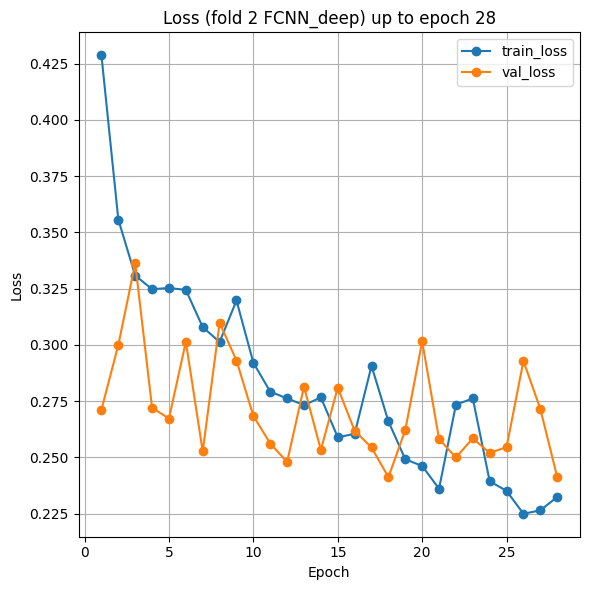

In [ ]:
plt.figure(figsize=(6,6))   # square
plt.plot(epochs, hist_cut['train_loss'], label='train_loss', marker='o')
plt.plot(epochs, hist_cut['val_loss'], label='val_loss', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title(f'Loss (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True)
plt.tight_layout()
loss_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_loss_square.png")
plt.savefig(loss_path, dpi=200, bbox_inches='tight')
plt.show(); plt.close()


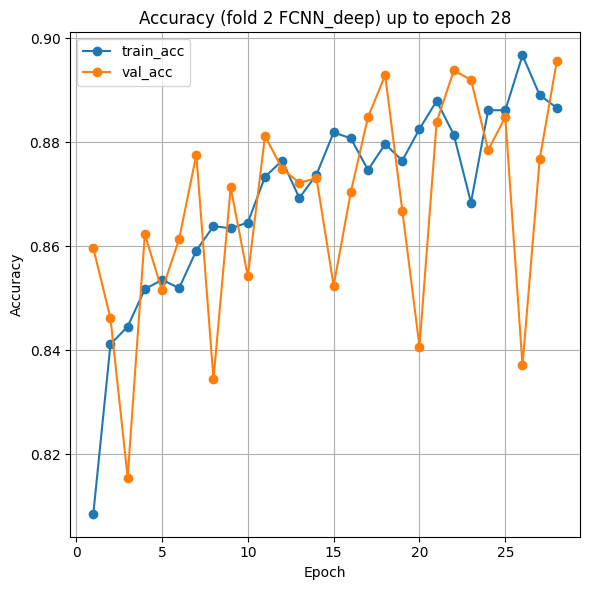

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(epochs, hist_cut['train_acc'], label='train_acc', marker='o')
plt.plot(epochs, hist_cut['val_acc'], label='val_acc', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.title(f'Accuracy (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True)
plt.tight_layout()
acc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_acc_square.png")
plt.savefig(acc_path, dpi=200, bbox_inches='tight')
plt.show(); plt.close()


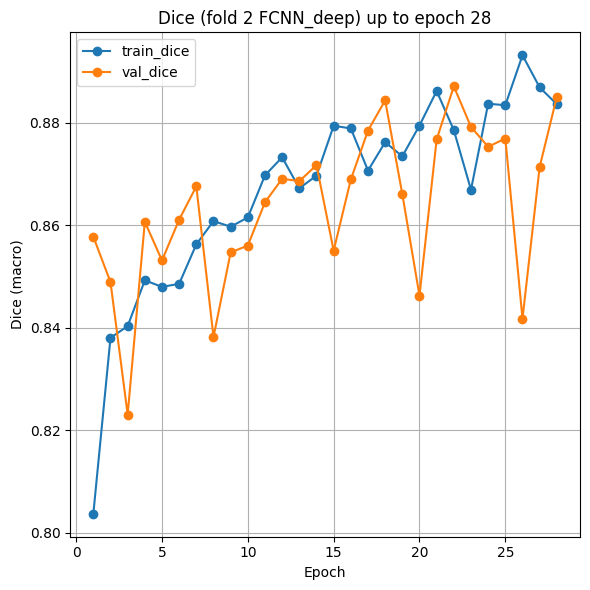

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(epochs, hist_cut['train_dice'], label='train_dice', marker='o')
plt.plot(epochs, hist_cut['val_dice'], label='val_dice', marker='o')
plt.xlabel('Epoch'); plt.ylabel('Dice (macro)')
plt.title(f'Dice (fold {best_fold} {best_model}) up to epoch {cutoff}')
plt.legend(); plt.grid(True)
plt.tight_layout()
dice_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_dice_square.png")
plt.savefig(dice_path, dpi=200, bbox_inches='tight')
plt.show(); plt.close()



Using OUT_DIR: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240
Best model/fold: FCNN_deep 2
Loaded scaler: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/scaler.joblib
Using feature columns count: 630
Loaded model: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth

--- Split: train ---
Rows matched in CSV: 3489; Accuracy: 0.9246
Class counts: {np.int64(0): np.int64(676), np.int64(1): np.int64(1134), np.int64(2): np.int64(1200), np.int64(3): np.int64(479)}

Classification report:
               precision    recall  f1-score   support

           0     0.8791    0.7530    0.8112       676
           1     0.9816    0.9868    0.9842      1134
           2     0.8668    0.9325    0.8984      1200
           3     1.0000    1.0000    1.0000       479

    accuracy                         0

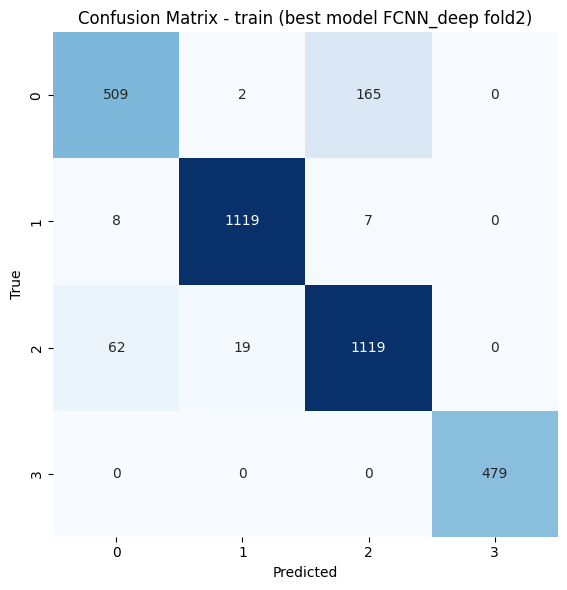

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_confmat_train.png

--- Split: val ---
Rows matched in CSV: 1039; Accuracy: 0.9211
Class counts: {np.int64(0): np.int64(91), np.int64(1): np.int64(380), np.int64(2): np.int64(400), np.int64(3): np.int64(168)}

Classification report:
               precision    recall  f1-score   support

           0     0.6182    0.7473    0.6766        91
           1     0.9617    0.9921    0.9767       380
           2     0.9322    0.8600    0.8947       400
           3     1.0000    1.0000    1.0000       168

    accuracy                         0.9211      1039
   macro avg     0.8780    0.8998    0.8870      1039
weighted avg     0.9265    0.9211    0.9226      1039



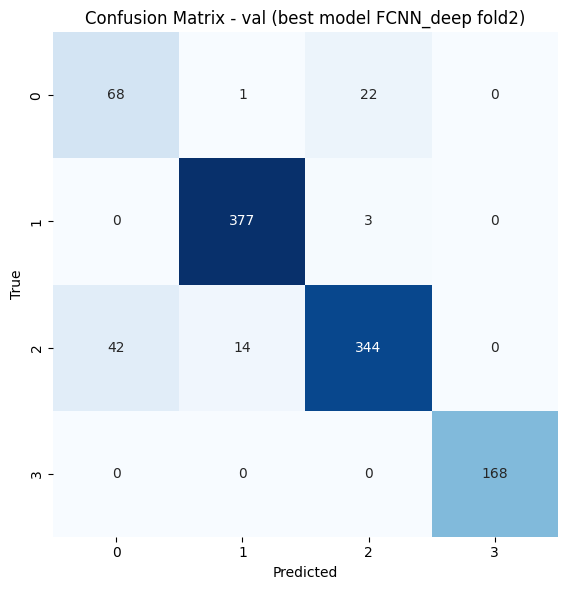

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_confmat_val.png

--- Split: test ---
Rows matched in CSV: 1027; Accuracy: 0.9182
Class counts: {np.int64(0): np.int64(79), np.int64(1): np.int64(380), np.int64(2): np.int64(399), np.int64(3): np.int64(169)}

Classification report:
               precision    recall  f1-score   support

           0     0.5593    0.8354    0.6701        79
           1     0.9663    0.9816    0.9739       380
           2     0.9463    0.8396    0.8898       399
           3     1.0000    1.0000    1.0000       169

    accuracy                         0.9182      1027
   macro avg     0.8680    0.9142    0.8834      1027
weighted avg     0.9328    0.9182    0.9221      1027



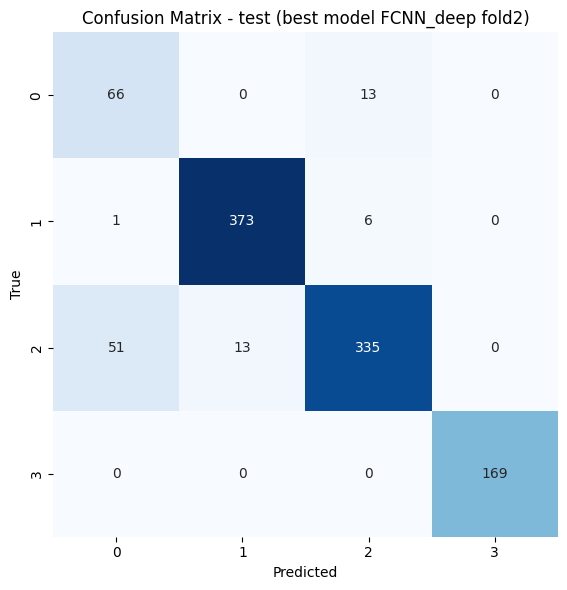

Saved: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_confmat_test.png

Done — confusion matrices + reports for train/val/test (based on CSV <-> folder mapping).


In [ ]:
# Paste into Colab
import os, glob, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import torch
import torch.nn.functional as F
import torch.nn as nn

# ---------------- USER params (change if needed) ----------------
BASE = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs"
INPUT_CSV = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
SEED = 42
N_FOLDS = 5
NUM_CLASSES = 4
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# folders to evaluate (exact paths you gave)
SPLIT_FOLDERS = {
    "train": "/content/drive/MyDrive/Colab Notebooks/dataset_final_split/train",
    "val":   "/content/drive/MyDrive/Colab Notebooks/dataset_final_split/val",
    "test":  "/content/drive/MyDrive/Colab Notebooks/dataset_final_split/test",
}
DPI = 200
FIGSIZE = (6,6)
# ----------------------------------------------------------------

# --- find latest experiment & best model/fold (same logic as yours) ---
exp_folders = sorted(glob.glob(os.path.join(BASE, "exp_*")), reverse=True)
if not exp_folders:
    raise FileNotFoundError("No experiment folders found in: " + BASE)
OUT_DIR = exp_folders[0]
print("Using OUT_DIR:", OUT_DIR)

cv_csv = os.path.join(OUT_DIR, "cv_summary.csv")
if not os.path.exists(cv_csv):
    raise FileNotFoundError("cv_summary.csv not found at: " + cv_csv)
cv = pd.read_csv(cv_csv)
best_row = cv.loc[cv['val_accuracy'].idxmax()].to_dict()
best_model = best_row['model']
best_fold = int(best_row['fold'])
print("Best model/fold:", best_model, best_fold)

# load model state
model_path = os.path.join(OUT_DIR, f"fold{best_fold}_{best_model}", f"{best_model}_fold{best_fold}_best.pth")
if not os.path.exists(model_path):
    model_path = best_row.get('model_path', model_path)
if not os.path.exists(model_path):
    raise FileNotFoundError("Best model .pth not found at: " + model_path)

# load scaler
scaler_path = os.path.join(OUT_DIR, "scaler.joblib")
if not os.path.exists(scaler_path):
    raise FileNotFoundError("scaler.joblib not found in experiment folder")
scaler = joblib.load(scaler_path)
print("Loaded scaler:", scaler_path)

# --- read CSV and build feature columns same as training ---
df = pd.read_csv(INPUT_CSV, low_memory=False)
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

# feature column reconstruction (same heuristic you used)
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
print("Using feature columns count:", len(FEATURE_COLS))

# helper: prepare X and y given a df subset
def prepare_X_y(subdf):
    X_df = subdf[FEATURE_COLS].copy()
    X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    means = X_df.mean()
    X_df = X_df.fillna(means).fillna(0.0)
    X_all = scaler.transform(X_df.values)
    y_all = subdf['label_idx'].values.astype(int)
    return X_all, y_all

# --- load model class and weights ---
class MLP_small(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(inplace=True),
            nn.Dropout(0.4),
            nn.Linear(1024, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self,x): return self.net(x)

class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

input_dim = len(FEATURE_COLS)
model = MLP_small(input_dim, NUM_CLASSES) if best_model == "MLP_small" else FCNN_deep(input_dim, NUM_CLASSES)
state = torch.load(model_path, map_location=DEVICE)
if 'model_state' in state:
    state = state['model_state']
model.load_state_dict(state)
model.to(DEVICE).eval()
print("Loaded model:", model_path)

# --- evaluation per split folder ---
for split_name, split_folder in SPLIT_FOLDERS.items():
    # Normalize path strings in CSV and folder
    norm_folder = os.path.normpath(split_folder)
    # locate rows whose image_path points under that folder
    # many CSVs store relative or absolute paths; handle both
    def path_in_folder(p):
        if pd.isna(p): return False
        pnorm = os.path.normpath(str(p))
        # exact startmatch or contains the folder path
        return pnorm.startswith(norm_folder) or (norm_folder in pnorm)
    mask = df['image_path'].apply(path_in_folder)
    subdf = df.loc[mask].reset_index(drop=True)
    if subdf.empty:
        print(f"\nNo rows found in CSV for split '{split_name}' using folder path:\n  {split_folder}\n-- Skipping.")
        continue

    X_split, y_split = prepare_X_y(subdf)
    # inference in batches
    bs = 256
    probs = []
    preds = []
    with torch.no_grad():
        for i in range(0, X_split.shape[0], bs):
            xb = torch.tensor(X_split[i:i+bs], dtype=torch.float32, device=DEVICE)
            logits = model(xb)
            p = F.softmax(logits, dim=1).cpu().numpy()
            probs.append(p); preds.append(p.argmax(axis=1))
    probs = np.vstack(probs)
    preds = np.concatenate(preds)

    # metrics
    cm = confusion_matrix(y_split, preds, labels=list(range(NUM_CLASSES)))
    acc = accuracy_score(y_split, preds)
    report = classification_report(y_split, preds, digits=4, zero_division=0)

    print(f"\n--- Split: {split_name} ---")
    print(f"Rows matched in CSV: {len(subdf)}; Accuracy: {acc:.4f}")
    print("Class counts:", dict(zip(*np.unique(y_split, return_counts=True))))
    print("\nClassification report:\n", report)

    # plot & save square confusion matrix
    plt.figure(figsize=FIGSIZE)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(range(NUM_CLASSES)),
                yticklabels=list(range(NUM_CLASSES)), square=True, cbar=False)
    plt.xlabel('Predicted'); plt.ylabel('True')
    plt.title(f'Confusion Matrix - {split_name} (best model {best_model} fold{best_fold})')
    out_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_confmat_{split_name}.png")
    plt.tight_layout(); plt.savefig(out_path, dpi=DPI, bbox_inches='tight'); plt.show(); plt.close()
    print("Saved:", out_path)

print("\nDone — confusion matrices + reports for train/val/test (based on CSV <-> folder mapping).")


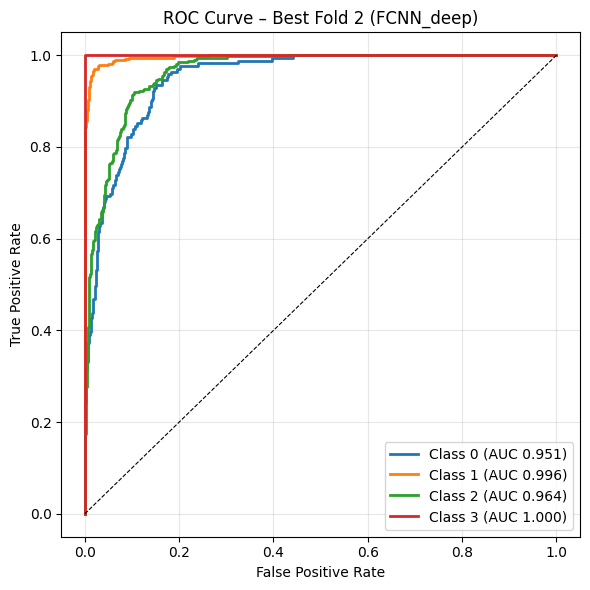

Saved ROC at: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/FCNN_deep_fold2_ROC_square.png


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
import numpy as np

# ----------- ensure you already have these loaded -----------
# model  -> your loaded best model (MLP_small or FCNN_deep)
# X_val  -> validation fold features
# y_val  -> validation fold labels
# NUM_CLASSES, DEVICE, best_model, best_fold available
# ------------------------------------------------------------

# run inference
bs = 256
probs = []
with torch.no_grad():
    for i in range(0, X_val.shape[0], bs):
        xb = torch.tensor(X_val[i:i+bs], dtype=torch.float32, device=DEVICE)
        logits = model(xb)
        p = F.softmax(logits, dim=1).cpu().numpy()
        probs.append(p)

probs = np.vstack(probs)

# -------- ROC Plot (square figure) --------
plt.figure(figsize=(6,6))

for c in range(NUM_CLASSES):
    try:
        fpr, tpr, _ = roc_curve((y_val==c).astype(int), probs[:,c])
        auc = roc_auc_score((y_val==c).astype(int), probs[:,c])
        plt.plot(fpr, tpr, label=f"Class {c} (AUC {auc:.3f})", linewidth=2)
    except Exception as e:
        print("Skipping class", c, ":", e)

# baseline
plt.plot([0,1],[0,1],'k--', linewidth=0.8)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve – Best Fold {best_fold} ({best_model})")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()

roc_path = os.path.join(OUT_DIR, f"{best_model}_fold{best_fold}_ROC_square.png")
plt.savefig(roc_path, dpi=200, bbox_inches='tight')
plt.show()

print("Saved ROC at:", roc_path)


In [ ]:
# FULL CELL: big stitched Grad-CAM++ explainability grid for multiple samples
# Paste into a new Colab notebook cell and run.

import os, math, cv2, json, joblib, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
import matplotlib.cm as cm
import torch, torch.nn as nn, torch.nn.functional as F
from torchvision import models, transforms

# ================== USER PATHS - EDIT if needed ==================
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR, "scaler.joblib")
RESNET_CKPT = "/content/drive/MyDrive/Colab Notebooks/best_model_fold5.pth"   # resnet used to create emb_
IMAGE_ROOT  = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
OUT_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/explainability"
os.makedirs(OUT_DIR, exist_ok=True)
# list of sample indices (indices into df_test, as in your previous cell)
SAMPLE_INDICES = [10, 49, 100, 150, 256, 400, 590, 750, 899, 1000]
# =================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -------------------- load dataframe & features --------------------
df = pd.read_csv(MERGED_CSV, low_memory=False)
if "label_idx" not in df.columns:
    raise KeyError("label_idx missing in CSV")
df = df[~df['label_idx'].isna()].reset_index(drop=True)
df['label_idx'] = df['label_idx'].astype(int)

CLASS_NAMES = ['hr','myopia','normal','rp']
NUM_CLASSES = len(CLASS_NAMES)

emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(['image_path','image_id','checkpoint_path','label_name','split'])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c!='label_idx')]
FEATURE_COLS = emb_cols + extra_numeric
emb_dim = len(emb_cols)
input_dim = len(FEATURE_COLS)
print(f"Features: emb={emb_dim}, clin={len(extra_numeric)} -> total {input_dim}")

# build X_all & df_test like you had
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)
scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
df_test = (df[df.get('split', pd.Series()).eq('test')] if 'split' in df.columns else df).reset_index().rename(columns={'index':'orig_idx'})
print("Test rows:", len(df_test))

# -------------------- model defs & load --------------------
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

fcnn = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state = torch.load(FCNN_CKPT, map_location=device)
# support wrapped dict or raw state_dict
if isinstance(state, dict) and 'model_state' in state:
    state = state['model_state']
fcnn.load_state_dict(state)
fcnn.eval()
print("Loaded FCNN from:", FCNN_CKPT)

# ResNet feature extractor loader
def _strip_prefixes(sd):
    new = {}
    for k,v in sd.items():
        nk = k
        for p in ["module.", "model."]:
            if nk.startswith(p): nk = nk[len(p):]
        new[nk] = v
    return new

def load_resnet18_as_extractor(checkpoint):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, NUM_CLASSES)  # temp head
    ckpt = torch.load(checkpoint, map_location='cpu')
    if isinstance(ckpt, dict) and any(k in ckpt for k in ["state_dict","model_state_dict"]):
        sd = ckpt.get("state_dict", ckpt.get("model_state_dict"))
        sd = _strip_prefixes(sd)
        model.load_state_dict(sd, strict=False)
    elif isinstance(ckpt, dict):
        sd = _strip_prefixes(ckpt)
        model.load_state_dict(sd, strict=False)
    else:
        model = ckpt
    model.fc = nn.Identity()
    model.to(device).eval()
    return model

resnet = load_resnet18_as_extractor(RESNET_CKPT)
print("Loaded ResNet extractor from:", RESNET_CKPT)

# -------------------- transforms & helpers --------------------
inference_tfms = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

def find_image_path(image_id_or_path):
    p = Path(str(image_id_or_path))
    if p.exists(): return str(p)
    if 'image_path' in df.columns:
        sub = df[df['image_path'] == image_id_or_path]
        if len(sub): return sub.iloc[0]['image_path']
    # search by name under IMAGE_ROOT
    for sp in ['train','val','test']:
        for cls in CLASS_NAMES:
            d = Path(IMAGE_ROOT)/sp/cls
            if d.exists():
                files = list(d.glob(f"{image_id_or_path}*"))
                if files: return str(files[0])
    # fallback rglob
    for f in Path(IMAGE_ROOT).rglob(f"*{image_id_or_path}*"):
        return str(f)
    return None

# -------------------- Grad-CAM++ and reason extraction --------------------
def compute_gradcam_pp_and_reasons(orig_idx):
    """
    returns: PIL original (224x224), PIL cam (224x224), reasons list (strings), pred_name, pred_prob, true_name
    """
    row = df_test.iloc[orig_idx]
    idx_in_df = int(row['orig_idx'])
    img_id = row.get('image_id', row.get('image_path', ''))
    true_idx = int(row['label_idx'])
    true_name = CLASS_NAMES[true_idx]

    img_path = find_image_path(img_id)
    if img_path is None:
        raise FileNotFoundError(f"Image not found for id {img_id}")

    # clinical raw from scaled X_all
    S_full = X_all[idx_in_df]
    S_clin = S_full[emb_dim:]
    mean_np = scaler.mean_; scale_np = scaler.scale_
    mean_clin = mean_np[emb_dim:]; scale_clin = scale_np[emb_dim:]
    clin_raw = S_clin * scale_clin + mean_clin
    clin_raw_t = torch.tensor(clin_raw, dtype=torch.float32, device=device).unsqueeze(0)

    # load image and forward through resnet with hooks
    pil = Image.open(img_path).convert('RGB')
    img_t = inference_tfms(pil).unsqueeze(0).to(device)

    activations = None
    gradients = None
    target_layer = resnet.layer4[-1].conv2

    def fwd_hook(m, i, o):
        nonlocal activations
        activations = o
    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0]

    h1 = target_layer.register_forward_hook(fwd_hook)
    h2 = target_layer.register_full_backward_hook(bwd_hook)

    # resnet forward
    x = img_t
    x = resnet.conv1(x); x = resnet.bn1(x); x = resnet.relu(x); x = resnet.maxpool(x)
    x = resnet.layer1(x); x = resnet.layer2(x); x = resnet.layer3(x); x = resnet.layer4(x)
    x_pool = resnet.avgpool(x)
    emb_raw = torch.flatten(x_pool, 1)  # (1, emb_dim)

    # concatenate and scale using scaler params
    mean_full = torch.tensor(scaler.mean_, dtype=torch.float32, device=device).unsqueeze(0)
    scale_full = torch.tensor(scaler.scale_, dtype=torch.float32, device=device).unsqueeze(0)
    full_raw = torch.cat([emb_raw, clin_raw_t], dim=1)
    full_scaled = (full_raw - mean_full) / (scale_full + 1e-6)

    # predict
    out = fcnn(full_scaled)
    probs = F.softmax(out, dim=1).detach().cpu().numpy().squeeze()
    pred_idx = int(np.argmax(probs)); pred_name = CLASS_NAMES[pred_idx]; pred_prob = float(probs[pred_idx])

    # backward for gradcam++ (wrt predicted class)
    score = out[0, pred_idx]
    fcnn.zero_grad(); resnet.zero_grad()
    score.backward(retain_graph=True)

    # remove hooks
    h1.remove(); h2.remove()

    # compute grad-cam++ map
    A = activations.detach()[0]   # (C,H,W)
    G = gradients.detach()[0]     # (C,H,W)
    eps = 1e-9
    alpha_num = G.pow(2)
    alpha_denom = 2 * G.pow(2) + (A * G.pow(3)).sum(dim=(1,2), keepdim=True)
    alpha = alpha_num / (alpha_denom + eps)
    weights = (alpha * torch.relu(G)).sum(dim=(1,2))
    cam = torch.relu((weights[:, None, None] * A).sum(dim=0))
    cam_np = cam.detach().cpu().numpy()
    cam_np = (cam_np - cam_np.min()) / (cam_np.max() - cam_np.min() + 1e-9)
    cam_up = cv2.resize(cam_np, (224,224), interpolation=cv2.INTER_CUBIC)
    cam_up = cv2.GaussianBlur((cam_up*255).astype('uint8'), (5,5), 1.0).astype(np.float32)/255.0

    base = np.array(pil.resize((224,224)).convert("RGB")).astype(np.float32)/255.0
    cmap = cm.get_cmap('jet')
    heat = cmap(cam_up)[...,:3]
    alpha_overlay = 0.45
    blended = (1.0-alpha_overlay)*base + alpha_overlay*heat
    blended = np.clip(blended, 0, 1)
    cam_pil = Image.fromarray((blended*255).astype('uint8'))

    # clinical feature importance using grad on scaled features
    full_scaled_t = full_scaled.clone().detach().requires_grad_(True)
    out2 = fcnn(full_scaled_t)
    score2 = out2[0, pred_idx]
    fcnn.zero_grad()
    score2.backward()
    grads_feat = full_scaled_t.grad.detach().cpu().numpy().squeeze()
    clin_grads = grads_feat[emb_dim:]
    imps = np.abs(clin_grads)
    signs = np.sign(clin_grads)
    top_idx = np.argsort(imps)[::-1][:6]
    reasons = []
    for rank, i in enumerate(top_idx, start=1):
        fname = extra_numeric[i]
        direction = 'increase' if signs[i]>0 else 'decrease' if signs[i]<0 else 'nochange'
        reasons.append(f"{rank}. {fname} ({direction})  |  imp={imps[i]:.6g}")

    return pil.resize((224,224)), cam_pil.resize((224,224)), reasons, pred_name, pred_prob, true_name

# -------------------- build big stitched image --------------------
def build_big_grid(test_indices, out_path, cols=3):
    rows = len(test_indices)
    # create matplotlib grid: rows x 3
    fig_w = 12
    fig_h = max(3*rows, 6)
    fig, axes = plt.subplots(rows, cols, figsize=(fig_w, fig_h))
    if rows == 1:
        axes = axes[np.newaxis, :]
    for r, tidx in enumerate(test_indices):
        print(f"Processing sample row {r+1}/{rows}: df_test idx {tidx}")
        try:
            orig, cam, reasons, pred_name, pred_prob, true_name = compute_gradcam_pp_and_reasons(tidx)
        except Exception as e:
            print("Skipping", tidx, "->", e)
            # blank row
            for c in range(cols):
                axes[r, c].axis('off')
            continue

        # col 0 original
        ax = axes[r,0]; ax.imshow(orig); ax.set_title(f"Original\nTrue: {true_name}", fontsize=9); ax.axis('off')
        # col 1 gradcam
        ax = axes[r,1]; ax.imshow(cam); ax.set_title(f"Grad-CAM++\nPred: {pred_name} (p={pred_prob:.3f})", fontsize=9); ax.axis('off')
        # col 2 text
        ax = axes[r,2]; ax.axis('off')
        txt_y = 0.95
        ax.text(0.01, txt_y, f"Sample: {tidx}", fontsize=9, fontweight='bold', va='top')
        txt_y -= 0.06
        ax.text(0.01, txt_y, f"Prediction: {pred_name} (p={pred_prob:.3f})", fontsize=9, va='top'); txt_y -= 0.06
        ax.text(0.01, txt_y, f"True: {true_name}", fontsize=9, va='top'); txt_y -= 0.08
        ax.text(0.01, txt_y, "Top clinical contributors:", fontsize=9, fontweight='bold', va='top'); txt_y -= 0.06
        for line in reasons:
            ax.text(0.02, txt_y, line, fontsize=8, va='top'); txt_y -= 0.05
            if txt_y < 0.02: break

    plt.tight_layout(h_pad=0.6)
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved big explain image to:", out_path)

# -------------------- run and save --------------------
out_file = os.path.join(OUT_DIR, "big_10_sample_explain_grid.png")
build_big_grid(SAMPLE_INDICES, out_file)
print("Done.")


Output hidden; open in https://colab.research.google.com to view.

fcnn final check

In [2]:
# Colab-ready: count images per class in train / val / test

import os
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
SPLITS = ["train", "val", "test"]
CLASSES = ["hr", "myopia", "normal", "rp"]

image_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

rows = []

for split in SPLITS:
    for cls in CLASSES:
        path = os.path.join(BASE_DIR, split, cls)
        if not os.path.exists(path):
            count = 0
        else:
            count = sum(
                1 for f in os.listdir(path)
                if f.lower().endswith(image_exts)
            )
        rows.append({
            "split": split,
            "class": cls,
            "image_count": count
        })

df = pd.DataFrame(rows)

# pivot for nice view
pivot = df.pivot(index="class", columns="split", values="image_count").fillna(0).astype(int)
pivot["total"] = pivot.sum(axis=1)

print("Image counts per class & split:\n")
display(pivot)

print("\nSplit totals:")
display(pivot.sum().to_frame(name="count"))

print("\nGrand total images:", pivot.sum().sum())


Image counts per class & split:



split,test,train,val,total
class,,,,
hr,209,676,215,1100
myopia,380,1136,380,1896
normal,399,1200,400,1999
rp,169,479,168,816



Split totals:


,count
split,
test,1157
train,3491
val,1163
total,5811



Grand total images: 11622


Device: cuda
DF shape after label cleanup: (5555, 640)
Using 512 emb_* + 118 numeric -> 630 total features
X_all: (5555, 630)  y_all: (5555,)
Loaded FCNN from: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/fold2_FCNN_deep/FCNN_deep_fold2_best.pth

--- Counting images from folder structure ---
train / hr: 373 images
train / myopia: 422 images
train / normal: 526 images
train / rp: 479 images
val / hr: 152 images
val / myopia: 125 images
val / normal: 178 images
val / rp: 168 images
test / hr: 145 images
test / myopia: 139 images
test / normal: 167 images
test / rp: 169 images

Split 'train': 1800 images mapped to CSV rows

Split 'val': 623 images mapped to CSV rows

Split 'test': 620 images mapped to CSV rows

=== Evaluating split: train ===
Total samples: 1800
Class distribution (from label_idx): {np.int64(0): np.int64(373), np.int64(1): np.int64(422), np.int64(2): np.int64(526), np.int64(3): np.int64(479)}
Accuracy: 0.9372222222

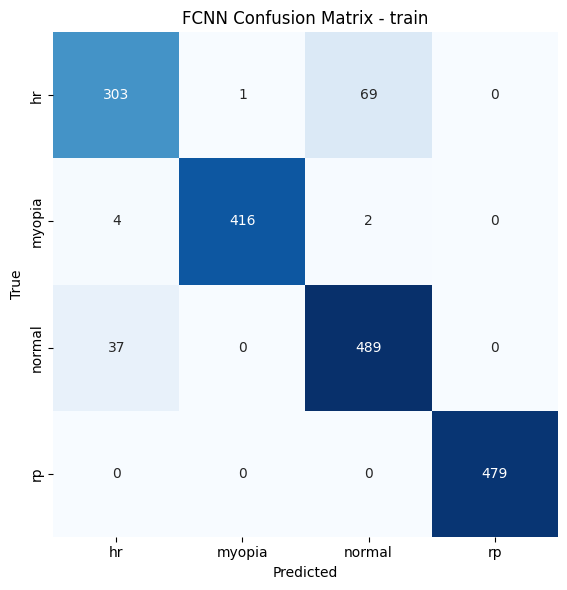

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/folder_split_fcnn_eval/FCNN_confmat_train.png

=== Evaluating split: val ===
Total samples: 623
Class distribution (from label_idx): {np.int64(0): np.int64(152), np.int64(1): np.int64(125), np.int64(2): np.int64(178), np.int64(3): np.int64(168)}
Accuracy: 0.9101123595505618

Classification report:
               precision    recall  f1-score   support

           0     0.8098    0.8684    0.8381       152
           1     0.9839    0.9760    0.9799       125
           2     0.8631    0.8146    0.8382       178
           3     1.0000    1.0000    1.0000       168

    accuracy                         0.9101       623
   macro avg     0.9142    0.9148    0.9140       623
weighted avg     0.9112    0.9101    0.9102       623



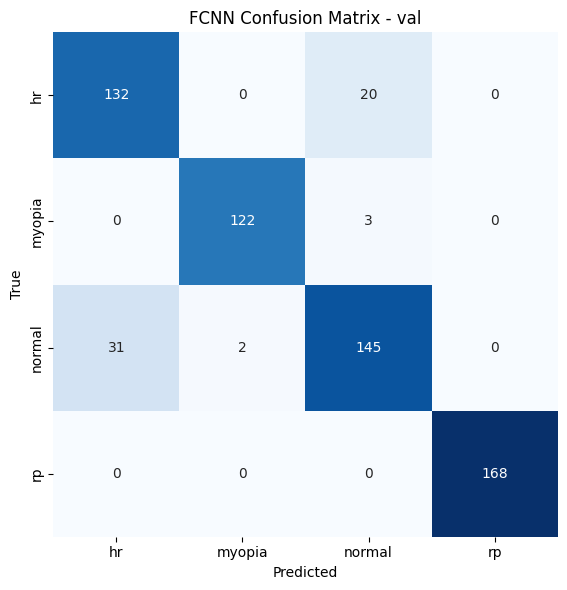

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/folder_split_fcnn_eval/FCNN_confmat_val.png

=== Evaluating split: test ===
Total samples: 620
Class distribution (from label_idx): {np.int64(0): np.int64(145), np.int64(1): np.int64(139), np.int64(2): np.int64(167), np.int64(3): np.int64(169)}
Accuracy: 0.9274193548387096

Classification report:
               precision    recall  f1-score   support

           0     0.8228    0.8966    0.8581       145
           1     0.9857    0.9928    0.9892       139
           2     0.9020    0.8263    0.8625       167
           3     1.0000    1.0000    1.0000       169

    accuracy                         0.9274       620
   macro avg     0.9276    0.9289    0.9275       620
weighted avg     0.9289    0.9274    0.9274       620



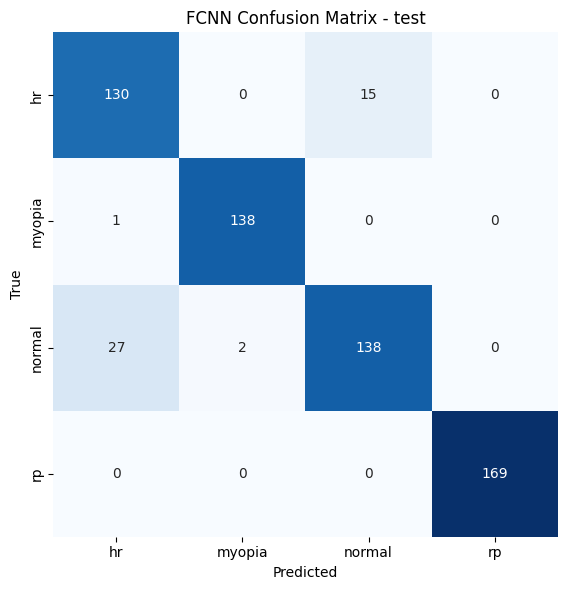

Saved confusion matrix to: /content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240/folder_split_fcnn_eval/FCNN_confmat_test.png

Done: FCNN confusion matrices computed for train / val / test using ONLY folder images.


In [4]:
# COLAB CELL: FCNN confusion matrices using ONLY images in dataset_final_split/*/*

import os, glob
from pathlib import Path

import numpy as np
import pandas as pd
import joblib

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

import matplotlib.pyplot as plt
import seaborn as sns

# =================== PATHS (EDIT IF NEEDED) ===================
DATA_ROOT   = "/content/drive/MyDrive/Colab Notebooks/dataset_final_split"
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR, "scaler.joblib")
OUT_DIR     = os.path.join(EXP_DIR, "folder_split_fcnn_eval")
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ["hr", "myopia", "normal", "rp"]
SPLITS = ["train", "val", "test"]
NUM_CLASSES = len(CLASS_NAMES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =================== LOAD CSV + FEATURES ===================
df = pd.read_csv(MERGED_CSV, low_memory=False)
if "label_idx" not in df.columns:
    raise KeyError("label_idx column missing in CSV")

df = df[~df["label_idx"].isna()].reset_index(drop=True)
df["label_idx"] = df["label_idx"].astype(int)

print("DF shape after label cleanup:", df.shape)

# feature columns same as training
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude_cols = set(["image_path", "image_id", "checkpoint_path", "label_name", "split"])
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if (c not in emb_cols and c not in exclude_cols and c != "label_idx")]
FEATURE_COLS = emb_cols + extra_numeric

emb_dim = len(emb_cols)
input_dim = len(FEATURE_COLS)
print(f"Using {emb_dim} emb_* + {len(extra_numeric)} numeric -> {input_dim} total features")

# clean + scale features (global, as in training)
X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
means = X_df.mean()
X_df = X_df.fillna(means).fillna(0.0)

scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df["label_idx"].values.astype(int)
print("X_all:", X_all.shape, " y_all:", y_all.shape)

# helper columns for filename matching
df["image_path"] = df.get("image_path", "").astype(str)
df["basename"] = df["image_path"].apply(os.path.basename)
df["stem"] = df["basename"].str.split(".").str[:-1].str.join(".")
if "image_id" in df.columns:
    df["image_id_str"] = df["image_id"].astype(str)
else:
    df["image_id_str"] = ""

# =================== FCNN MODEL ===================
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

model = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state = torch.load(FCNN_CKPT, map_location=device)
# support wrapped checkpoint dicts
if isinstance(state, dict) and "model_state" in state:
    state = state["model_state"]
model.load_state_dict(state)
model.eval()
print("Loaded FCNN from:", FCNN_CKPT)

# =================== HELPER: MAP IMAGE FILE -> DF ROW ===================
def find_df_index_for_file(path_str: str):
    """
    Try several heuristics to map an image file path to a row in df.
    Returns index in df or None.
    """
    bn = os.path.basename(path_str)
    stem = os.path.splitext(bn)[0]

    # 1) exact full path match (if CSV stored same absolute path)
    m = df.index[df["image_path"] == path_str].tolist()
    if m:
        return m[0]

    # 2) basename match
    m = df.index[df["basename"] == bn].tolist()
    if m:
        return m[0]

    # 3) stem match
    m = df.index[df["stem"] == stem].tolist()
    if m:
        return m[0]

    # 4) image_id match (if present)
    m = df.index[df["image_id_str"] == bn].tolist()
    if m:
        return m[0]
    m = df.index[df["image_id_str"] == stem].tolist()
    if m:
        return m[0]

    return None

# =================== BUILD INDEXES BY FOLDER ===================
split_indices = {s: [] for s in SPLITS}
split_missing = {s: [] for s in SPLITS}

print("\n--- Counting images from folder structure ---")
for split in SPLITS:
    for cls_idx, cls in enumerate(CLASS_NAMES):
        folder = os.path.join(DATA_ROOT, split, cls)
        files = []
        if os.path.isdir(folder):
            for ext in ("*.jpg", "*.jpeg", "*.png", "*.tif", "*.tiff", "*.bmp"):
                files.extend(glob.glob(os.path.join(folder, ext)))
        files = sorted(files)
        print(f"{split} / {cls}: {len(files)} images")

        for fpath in files:
            idx = find_df_index_for_file(fpath)
            if idx is None:
                split_missing[split].append(fpath)
            else:
                split_indices[split].append(idx)

for s in SPLITS:
    print(f"\nSplit '{s}': {len(split_indices[s])} images mapped to CSV rows")
    if split_missing[s]:
        print(f"  WARNING: {len(split_missing[s])} files could not be matched to CSV (first 5):")
        for p in split_missing[s][:5]:
            print("   -", p)

# =================== RUN FCNN & CONFUSION MATRICES ===================
def eval_split(name, idx_list):
    if not idx_list:
        print(f"\nSplit {name}: no samples, skipping.")
        return

    idx_arr = np.array(idx_list, dtype=int)
    X = X_all[idx_arr]
    y_true = y_all[idx_arr]

    print(f"\n=== Evaluating split: {name} ===")
    print("Total samples:", len(y_true))
    print("Class distribution (from label_idx):", dict(zip(*np.unique(y_true, return_counts=True))))

    # inference
    bs = 256
    preds = []
    with torch.no_grad():
        for i in range(0, X.shape[0], bs):
            xb = torch.tensor(X[i:i+bs], dtype=torch.float32, device=device)
            logits = model(xb)
            p = torch.softmax(logits, dim=1)
            preds.append(p.argmax(dim=1).cpu().numpy())
    preds = np.concatenate(preds)

    acc = accuracy_score(y_true, preds)
    cm = confusion_matrix(y_true, preds, labels=list(range(NUM_CLASSES)))
    print("Accuracy:", acc)
    print("\nClassification report:\n", classification_report(y_true, preds, digits=4, zero_division=0))

    # square confusion matrix plot
    plt.figure(figsize=(6,6))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        square=True,
        cbar=False
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"FCNN Confusion Matrix - {name}")
    plt.tight_layout()

    out_path = os.path.join(OUT_DIR, f"FCNN_confmat_{name}.png")
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved confusion matrix to:", out_path)
    return cm, acc

cm_train, acc_train = eval_split("train", split_indices["train"])
cm_val,   acc_val   = eval_split("val",   split_indices["val"])
cm_test,  acc_test  = eval_split("test",  split_indices["test"])

print("\nDone: FCNN confusion matrices computed for train / val / test using ONLY folder images.")


Device: cuda
Total samples in CSV: 5555
split
train    3489
val      1039
test     1027
Name: count, dtype: int64
Total features: 630
Loaded FCNN checkpoint

=== TRAIN ===
Samples: 3489
Accuracy: 0.9246
              precision    recall  f1-score   support

          hr     0.8791    0.7530    0.8112       676
      myopia     0.9816    0.9868    0.9842      1134
      normal     0.8668    0.9325    0.8984      1200
          rp     1.0000    1.0000    1.0000       479

    accuracy                         0.9246      3489
   macro avg     0.9319    0.9181    0.9234      3489
weighted avg     0.9248    0.9246    0.9233      3489



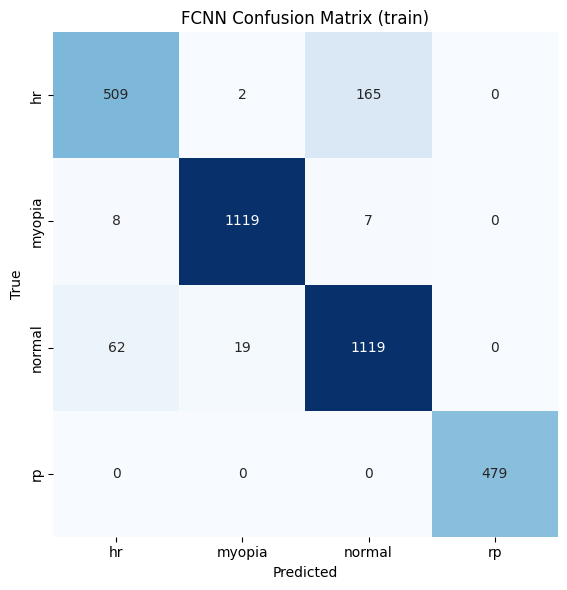


=== VAL ===
Samples: 1039
Accuracy: 0.9201
              precision    recall  f1-score   support

          hr     0.6182    0.7473    0.6766        91
      myopia     0.9593    0.9921    0.9754       380
      normal     0.9321    0.8575    0.8932       400
          rp     1.0000    1.0000    1.0000       168

    accuracy                         0.9201      1039
   macro avg     0.8774    0.8992    0.8863      1039
weighted avg     0.9255    0.9201    0.9216      1039



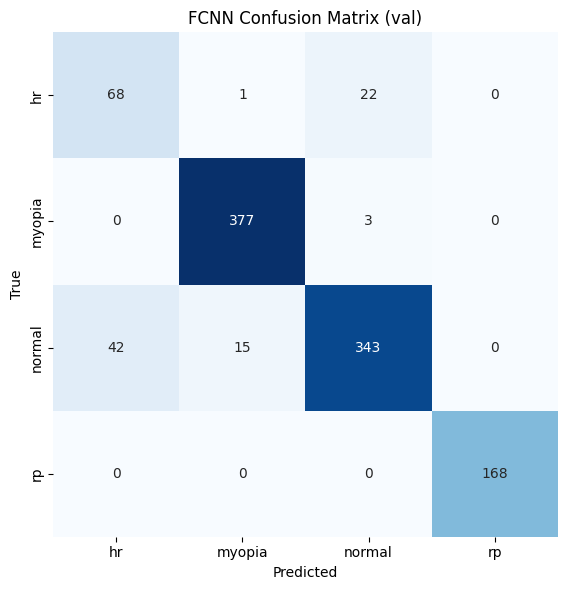


=== TEST ===
Samples: 1027
Accuracy: 0.9182
              precision    recall  f1-score   support

          hr     0.5593    0.8354    0.6701        79
      myopia     0.9663    0.9816    0.9739       380
      normal     0.9463    0.8396    0.8898       399
          rp     1.0000    1.0000    1.0000       169

    accuracy                         0.9182      1027
   macro avg     0.8680    0.9142    0.8834      1027
weighted avg     0.9328    0.9182    0.9221      1027



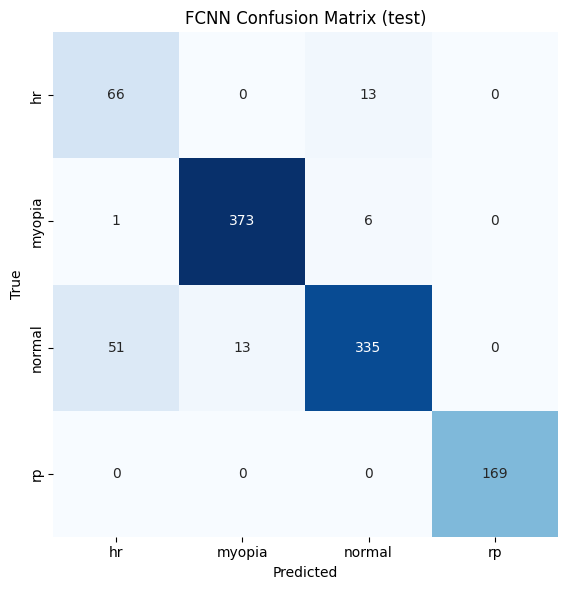


✅ Official FCNN confusion matrices generated from CSV used in training.


In [8]:
# COLAB CELL: FCNN confusion matrices using merged_fundus_features.csv (TRAINING TRUTH)

import os
import numpy as np
import pandas as pd
import joblib
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ================== PATHS ==================
MERGED_CSV  = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/merged_fundus_features.csv"
EXP_DIR     = "/content/drive/MyDrive/Colab Notebooks/fundus_project/outputs/fundus_training_runs/exp_20251104_152240"
FCNN_CKPT   = os.path.join(EXP_DIR, "fold2_FCNN_deep/FCNN_deep_fold2_best.pth")
SCALER_PATH = os.path.join(EXP_DIR, "scaler.joblib")
OUT_DIR     = os.path.join(EXP_DIR, "csv_truth_confusion_matrices")
os.makedirs(OUT_DIR, exist_ok=True)

CLASS_NAMES = ["hr", "myopia", "normal", "rp"]
NUM_CLASSES = len(CLASS_NAMES)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ================== LOAD CSV ==================
df = pd.read_csv(MERGED_CSV, low_memory=False)
df = df[~df["label_idx"].isna()].reset_index(drop=True)
df["label_idx"] = df["label_idx"].astype(int)

assert "split" in df.columns, "split column missing in CSV"

print("Total samples in CSV:", len(df))
print(df["split"].value_counts())

# ================== FEATURE BUILD ==================
emb_cols = [c for c in df.columns if c.startswith("emb_")]
exclude = {"image_path","image_id","checkpoint_path","label_name","split","label_idx"}
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
extra_numeric = [c for c in numeric_cols if c not in emb_cols and c not in exclude]

FEATURE_COLS = emb_cols + extra_numeric
input_dim = len(FEATURE_COLS)
print("Total features:", input_dim)

X_df = df[FEATURE_COLS].copy()
X_df.replace([np.inf, -np.inf], np.nan, inplace=True)
X_df = X_df.fillna(X_df.mean()).fillna(0.0)

scaler = joblib.load(SCALER_PATH)
X_all = scaler.transform(X_df.values)
y_all = df["label_idx"].values

# ================== FCNN MODEL ==================
class FCNN_deep(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 2048)
        self.bn1 = nn.BatchNorm1d(2048)
        self.fc2 = nn.Linear(2048, 1024)
        self.fc3 = nn.Linear(1024, 512)
        self.out = nn.Linear(512, num_classes)
        self.drop = nn.Dropout(0.4)
    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.drop(x)
        x = F.relu(self.fc2(x))
        x = self.drop(x)
        x = F.relu(self.fc3(x))
        x = self.drop(x)
        return self.out(x)

model = FCNN_deep(input_dim, NUM_CLASSES).to(device)
state = torch.load(FCNN_CKPT, map_location=device)
if "model_state" in state: state = state["model_state"]
model.load_state_dict(state)
model.eval()
print("Loaded FCNN checkpoint")

# ================== EVAL FUNCTION ==================
def eval_split(split_name):
    sub = df[df["split"] == split_name]
    X = X_all[sub.index]
    y_true = y_all[sub.index]

    # inference
    bs = 256
    preds = []
    with torch.no_grad():
        for i in range(0, len(X), bs):
            xb = torch.tensor(X[i:i+bs], dtype=torch.float32, device=device)
            logits = model(xb)
            preds.append(torch.softmax(logits, 1).argmax(1).cpu().numpy())
    preds = np.concatenate(preds)

    acc = accuracy_score(y_true, preds)
    cm = confusion_matrix(y_true, preds, labels=range(NUM_CLASSES))

    print(f"\n=== {split_name.upper()} ===")
    print("Samples:", len(sub))
    print("Accuracy:", round(acc, 4))
    print(classification_report(y_true, preds, target_names=CLASS_NAMES, digits=4))

    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES,
                square=True, cmap="Blues", cbar=False)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"FCNN Confusion Matrix ({split_name})")
    plt.tight_layout()

    out = os.path.join(OUT_DIR, f"FCNN_confmat_{split_name}.png")
    plt.savefig(out, dpi=200, bbox_inches="tight")
    plt.show()

# ================== RUN ==================
for sp in ["train", "val", "test"]:
    eval_split(sp)

print("\n✅ Official FCNN confusion matrices generated from CSV used in training.")
